<a href="https://colab.research.google.com/github/Zinc-zn/PVCK_Ganjil_2026/blob/main/Pertemuan%207/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laporan Jobsheet Pertemuan 07

**Modul 7 – Segmentasi Citra dengan Thresholding**

**Nama  : Mochammad Rijal Dzaki Rifki Afifudin**

**NIM   : 244107020240**

**Kelas : TI-3C**

---
## A. Tujuan Praktikum

1. Menjelaskan konsep segmentasi citra dan posisi *thresholding* di antara metode segmentasi lain.
2. Menerapkan lima jenis **global threshold**, **adaptive threshold**, dan **Otsu** dengan OpenCV, serta mengimplementasikannya secara **manual** dengan NumPy.
3. Memilih metode dan nilai threshold berdasarkan **histogram** dan kondisi pencahayaan citra.
4. Mengevaluasi hasil segmentasi secara kuantitatif memakai **IoU, Dice, dan pixel accuracy**.
5. Menerapkan **K-Means** untuk segmentasi warna dan merangkai segmentasi dengan pasca-proses morfologi dan **OCR**.

## B. Ulasan Singkat Teori

**Segmentasi** = membagi citra menjadi region/area dengan kemiripan sifat (intensitas, warna, tekstur)
untuk memisahkan objek (*foreground*) dari latar (*background*).

| Kelompok prinsip | Contoh metode |
|---|---|
| Thresholding | Global, adaptive, Otsu, multi-Otsu, Triangle, Sauvola |
| Berbasis tepi | Sobel, Canny, Roberts |
| Berbasis region | Region growing, split & merge, watershed, mean shift |
| Clustering | K-Means, mean shift, GMM |
| Kontur aktif | Snake, level set |
| Deep learning | U-Net, Mask R-CNN, SAM |

**Global threshold** memakai satu nilai `T` konstan untuk seluruh citra:

$$g(x,y)=\begin{cases}\text{maks} & f(x,y) > T\\ 0 & f(x,y) \le T\end{cases}$$

**Adaptive (local) threshold** memakai `T` yang **berubah** mengikuti rata-rata lingkungan lokal tiap piksel:
`T(x,y) = mean/gaussian(jendela b×b di sekitar (x,y)) − C`.

**Otsu threshold** mencari `T` **otomatis** dengan memaksimalkan *between-class variance*
(≡ meminimalkan *intra-class variance*):

$$\sigma_B^2(t)=\omega_0(t)\,\omega_1(t)\,\big[\mu_0(t)-\mu_1(t)\big]^2,\qquad T^*=\arg\max_t \sigma_B^2(t)$$

---
## C. ULASAN TEORI — Percobaan

Bagian ini menjalankan langsung rumus-rumus **C. ULASAN TEORI** modul:

1. **C.1** Histogram & citra biner hasil threshold
2. **C.2** Lima **global threshold** manual (sesuai tabel ketentuan modul)
3. **C.3** **Adaptive threshold** manual (mean & Gaussian) pada citra ber-pencahayaan tidak merata
4. **C.4** **Otsu** manual + tabel perhitungan *weight/mean/variance* contoh 6×6 modul
5. **C.5** **K-Means** untuk segmentasi warna

### C.0 Mount Google Drive & Import Library

In [ ]:
# ── C.0  Mount Google Drive & import library ─────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
import os
import re
import sys
import time
import subprocess
import pandas as pd

# ── Mount Google Drive ───────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Lokasi citra di Google Drive ─────────────────────────────────────
base_path = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/'

def imgpath(nama):
    """Gabungkan base_path dengan nama berkas citra."""
    return os.path.join(base_path, nama)

# ── Pastikan seluruh citra yang dibutuhkan tersedia ──────────────────
CONTOH_CEK = ['lena.jpg', 'lena_gs_lc2.jpg', 'sudoku-original.jpg', 'gradient.jpg',
              'lily.jpg', 'KTPDummy.jpg', 'ktp_fulan.jpg']
hilang = [f for f in CONTOH_CEK if not os.path.exists(imgpath(f))]
if hilang:
    print('⚠️  Berkas citra TIDAK ditemukan:', hilang)
    print('   base_path =', base_path)
    print('   → Jalankan  !ls /content/drive/MyDrive/  lalu sesuaikan `base_path`')
    print('     pada sel ini dengan lokasi folder Images di Drive Anda.')
else:
    print('✅ Semua citra yang dibutuhkan tersedia di:', base_path)

# Parameter adaptive threshold khusus bagian D2 (hasil uji beberapa nilai;
# C kecil membuat latar KTP terpecah menjadi bercak yang mengganggu OCR).
BS_D2, C_D2 = 11, 10

print('base_path :', base_path)
print('OpenCV    :', cv.__version__, '| NumPy:', np.__version__)

### C.1 Histogram dan Citra Biner Hasil Threshold

Contoh pada modul (Gambar 1 & 2): objek terang di atas latar gelap. Histogram memperlihatkan
**dua grup dominan** yang dapat dipisahkan oleh satu nilai threshold `T`.

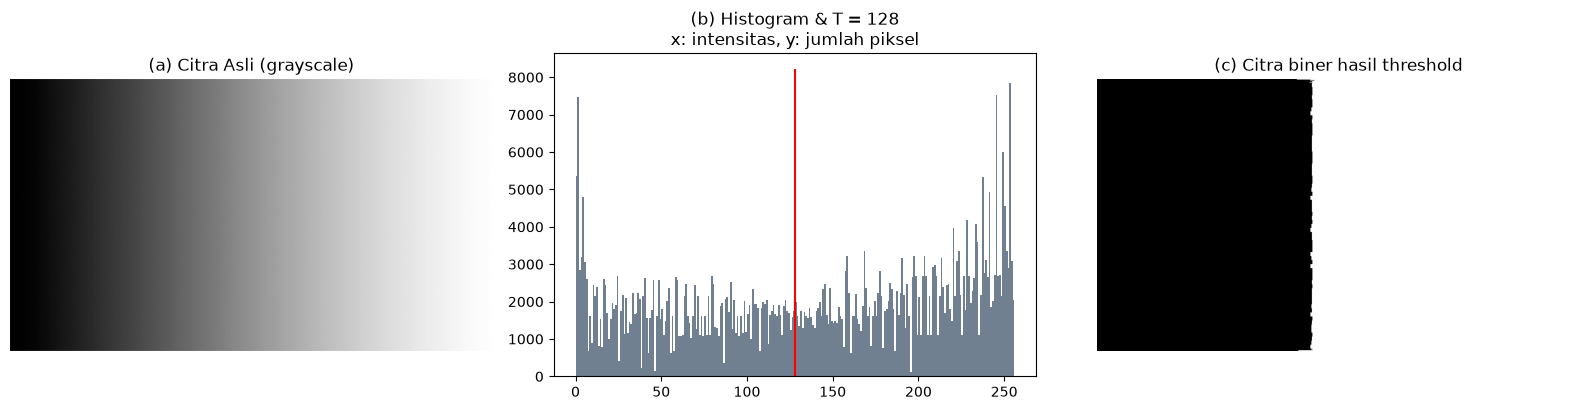

Piksel objek (nilai > 128) : 287,906
Piksel latar (nilai <= 128) : 230,494
Nilai unik hasil biner     : [  0 255]


In [2]:
# ── C.1  Thresholding sebagai bentuk segmentasi paling sederhana ─────
img_c1  = cv.imread(imgpath('gradient.jpg'))
gray_c1 = cv.cvtColor(img_c1, cv.COLOR_BGR2GRAY)

T = 128
_, biner_c1 = cv.threshold(gray_c1, T, 255, cv.THRESH_BINARY)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].imshow(gray_c1, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('(a) Citra Asli (grayscale)'); ax[0].axis('off')

ax[1].hist(gray_c1.ravel(), bins=256, range=(0, 256), color='slategray')
ax[1].vlines(T, 0, ax[1].get_ylim()[1], colors='red')
ax[1].set_title(f'(b) Histogram & T = {T}\nx: intensitas, y: jumlah piksel')

ax[2].imshow(biner_c1, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('(c) Citra biner hasil threshold'); ax[2].axis('off')
plt.tight_layout(); plt.show()

print(f'Piksel objek (nilai > {T}) : {(gray_c1 > T).sum():,}')
print(f'Piksel latar (nilai <= {T}) : {(gray_c1 <= T).sum():,}')
print('Nilai unik hasil biner     :', np.unique(biner_c1))

### C.2 Lima Global Threshold — Implementasi Manual

Mengikuti tabel ketentuan modul (**threshold = 200**):

| Jenis Global Threshold | Jika piksel > thresh | Jika piksel ≤ thresh |
|---|---|---|
| `BINARY` | menjadi nilai maksimal | menjadi 0 |
| `BINARY_INV` | menjadi 0 | menjadi nilai maksimal |
| `TRUNC` | menjadi thresh | nilai asli tetap |
| `TOZERO` | nilai asli tetap | menjadi 0 |
| `TOZERO_INV` | menjadi 0 | nilai asli tetap |

Fungsi di bawah **tidak memakai** `cv.threshold()` — hanya operasi NumPy murni.

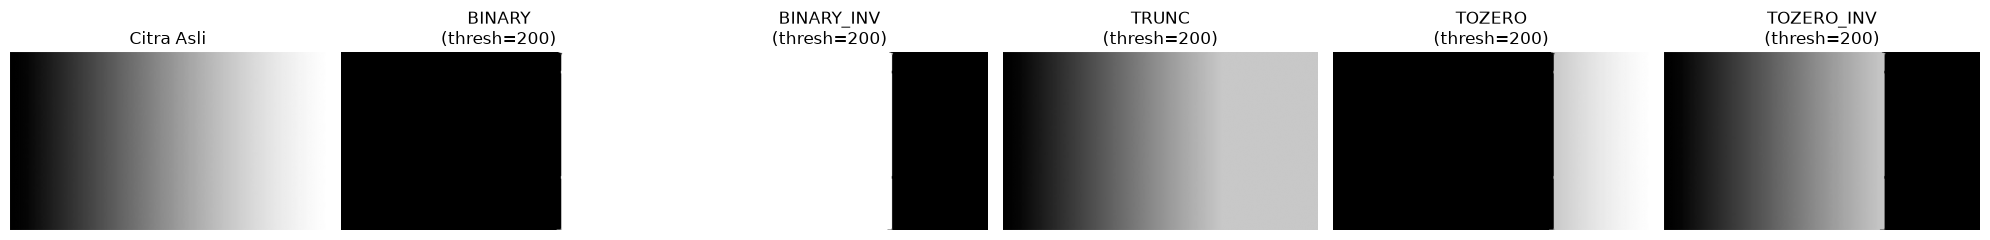

In [3]:
# ── C.2  Fungsi global threshold manual (murni NumPy) ────────────────
def global_threshold_manual(img, thresh=200, maxval=255, jenis='BINARY'):
    """Lima jenis global threshold dihitung manual dengan operasi NumPy.

    Parameter
    ---------
    img    : citra grayscale (H,W) uint8
    thresh : nilai ambang T
    maxval : nilai maksimal (biasanya 255)
    jenis  : 'BINARY' | 'BINARY_INV' | 'TRUNC' | 'TOZERO' | 'TOZERO_INV'
    """
    s = img.astype(np.int32)                     # hindari overflow uint8
    if   jenis == 'BINARY':      out = np.where(s >  thresh, maxval, 0)
    elif jenis == 'BINARY_INV':  out = np.where(s >  thresh, 0, maxval)
    elif jenis == 'TRUNC':       out = np.where(s >  thresh, thresh, s)
    elif jenis == 'TOZERO':      out = np.where(s >  thresh, s, 0)
    elif jenis == 'TOZERO_INV':  out = np.where(s >  thresh, 0, s)
    else: raise ValueError('jenis tidak dikenal: ' + jenis)
    return out.astype(np.uint8)

THRESH = 200
img_c2  = cv.imread(imgpath('gradient.jpg'))
gray_c2 = cv.cvtColor(img_c2, cv.COLOR_BGR2GRAY)

jenis_list   = ['BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
hasil_manual = {j: global_threshold_manual(gray_c2, THRESH, 255, j) for j in jenis_list}

fig, ax = plt.subplots(1, 6, figsize=(20, 3.6))
ax[0].imshow(gray_c2, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Citra Asli'); ax[0].axis('off')
for k, j in enumerate(jenis_list, start=1):
    ax[k].imshow(hasil_manual[j], cmap='gray', vmin=0, vmax=255)
    ax[k].set_title(f'{j}\n(thresh={THRESH})'); ax[k].axis('off')
plt.tight_layout(); plt.show()

In [4]:
# ── C.2b  Verifikasi hasil manual terhadap cv.threshold() ────────────
pasangan = {'BINARY': cv.THRESH_BINARY, 'BINARY_INV': cv.THRESH_BINARY_INV,
            'TRUNC': cv.THRESH_TRUNC,  'TOZERO': cv.THRESH_TOZERO,
            'TOZERO_INV': cv.THRESH_TOZERO_INV}

print(f"{'Jenis':<12}{'Rata-rata Manual':>18}{'Rata-rata OpenCV':>18}{'Identik':>10}")
print('-' * 58)
for j, flag in pasangan.items():
    _, lib = cv.threshold(gray_c2, THRESH, 255, flag)
    sama = float((hasil_manual[j] == lib).mean() * 100)
    print(f'{j:<12}{hasil_manual[j].mean():>18.2f}{lib.mean():>18.2f}{sama:>9.1f}%')
print('\nSemua jenis 100% identik dengan OpenCV ⇒ implementasi manual sudah tepat.')

Jenis         Rata-rata Manual  Rata-rata OpenCV   Identik
----------------------------------------------------------
BINARY                   77.05             77.05    100.0%
BINARY_INV              177.95            177.95    100.0%
TRUNC                   128.83            128.83    100.0%
TOZERO                   69.89             69.89    100.0%
TOZERO_INV               68.40             68.40    100.0%

Semua jenis 100% identik dengan OpenCV ⇒ implementasi manual sudah tepat.


### C.3 Adaptive Threshold — Implementasi Manual

Dipakai citra **sudoku** yang pencahayaannya **tidak merata** (bagian atas lebih terang).
Sesuai ketentuan modul: **jendela 11×11, C = 2, sigma = 2** untuk Gaussian.

Adaptive threshold manual dihitung dari:

* **Mean** → `T(x,y) = rata-rata(jendela b×b)` (dihitung cepat dengan *integral image* / `cumsum`),
* **Gaussian** → `T(x,y) = konvolusi(jendela b×b, kernel Gaussian σ, hasil dinormalisasi)`.

Fungsi `cv.threshold()`, `cv.adaptiveThreshold()`, maupun filter siap-pakai
(`cv.blur`, `cv.GaussianBlur`, `cv.filter2D`) **tidak digunakan**.

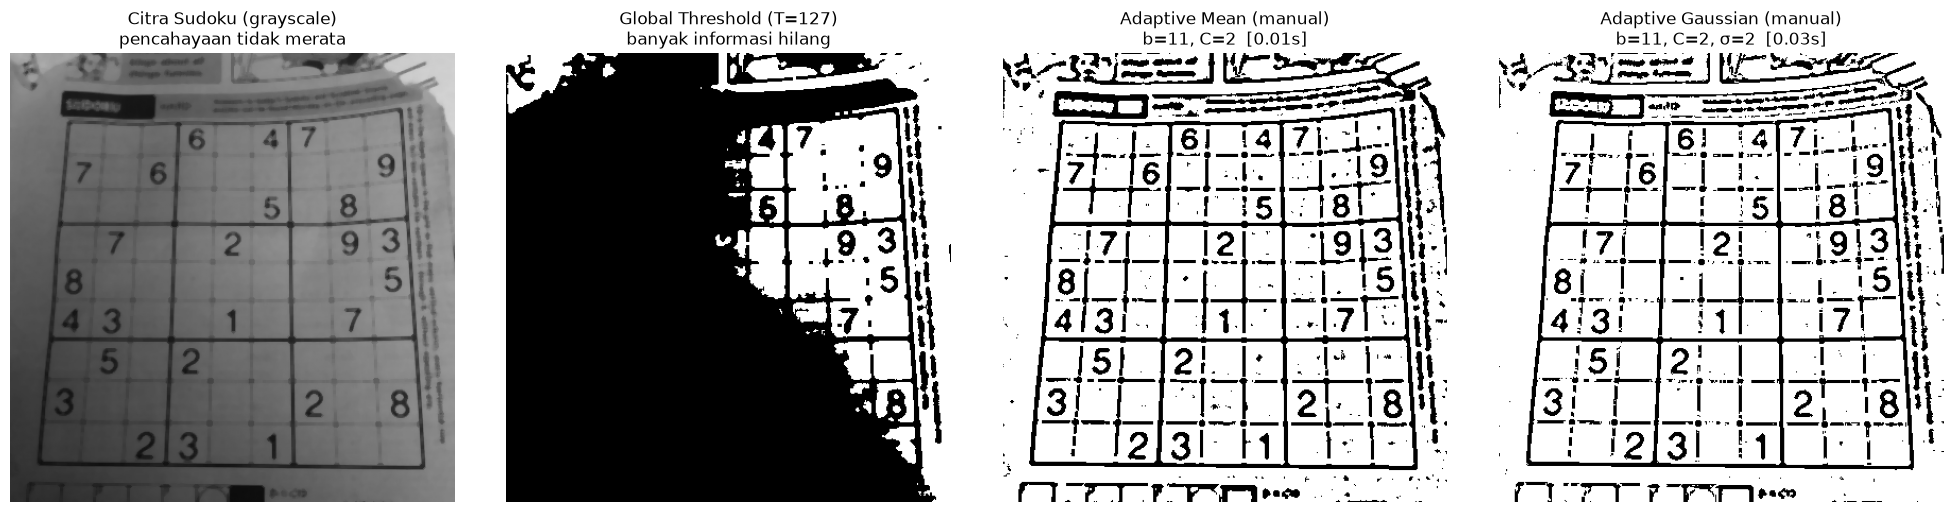

In [5]:
# ── C.3  Adaptive threshold MANUAL ───────────────────────────────────
def _pad_reflect(img, pad):
    return np.pad(img.astype(np.float64), pad, mode='reflect')

def local_mean(img, b):
    """Rata-rata lokal jendela b x b memakai integral image (cumulative sum)."""
    pad = b // 2
    p   = _pad_reflect(img, pad)
    ii  = np.pad(p.cumsum(0).cumsum(1), ((1, 0), (1, 0)))   # integral image + border 0
    H, W = img.shape
    S = ii[b:b+H, b:b+W] - ii[0:H, b:b+W] - ii[b:b+H, 0:W] + ii[0:H, 0:W]
    return S / (b * b)

def gaussian_kernel_1d(b, sigma):
    """Kernel Gaussian 1D yang dinormalisasi agar jumlahnya = 1."""
    ax = np.arange(b) - b // 2
    k  = np.exp(-(ax ** 2) / (2.0 * sigma ** 2))
    return k / k.sum()

def local_gaussian(img, b, sigma):
    """Rata-rata Gaussian lokal — konvolusi separable manual (tanpa library filter)."""
    pad = b // 2
    p   = _pad_reflect(img, pad)
    k   = gaussian_kernel_1d(b, sigma)
    H, W = img.shape
    tmp = np.zeros((H, p.shape[1]))                 # konvolusi arah vertikal
    for i, ki in enumerate(k):
        tmp += ki * p[i:i+H, :]
    out = np.zeros((H, W))                          # konvolusi arah horizontal
    for j, kj in enumerate(k):
        out += kj * tmp[:, j:j+W]
    return out

def adaptive_threshold_manual(img, block_size=11, C=2, metode='mean', sigma=2):
    """Adaptive threshold manual. Piksel = 255 bila img > T(x,y), dengan T = lokal - C."""
    lokal = local_mean(img, block_size) if metode == 'mean' else local_gaussian(img, block_size, sigma)
    return np.where(img > (lokal - C), 255, 0).astype(np.uint8)

# ── Citra sudoku (pencahayaan tidak merata) ──────────────────────────
img_c3   = cv.imread(imgpath('sudoku-original.jpg'))
citra_c3 = cv.medianBlur(img_c3, 5)                 # peredam noise (bukan filter threshold)
gray_c3  = cv.cvtColor(citra_c3, cv.COLOR_BGR2GRAY)

B, CC, SIGMA = 11, 2, 2
t0 = time.time(); adap_mean = adaptive_threshold_manual(gray_c3, B, CC, 'mean');         t1 = time.time()
t2 = time.time(); adap_gaus = adaptive_threshold_manual(gray_c3, B, CC, 'gauss', SIGMA); t3 = time.time()
_, global_c3 = cv.threshold(gray_c3, 127, 255, cv.THRESH_BINARY)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(gray_c3, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Citra Sudoku (grayscale)\npencahayaan tidak merata'); ax[0].axis('off')
ax[1].imshow(global_c3, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Global Threshold (T=127)\nbanyak informasi hilang'); ax[1].axis('off')
ax[2].imshow(adap_mean, cmap='gray', vmin=0, vmax=255)
ax[2].set_title(f'Adaptive Mean (manual)\nb={B}, C={CC}  [{t1-t0:.2f}s]'); ax[2].axis('off')
ax[3].imshow(adap_gaus, cmap='gray', vmin=0, vmax=255)
ax[3].set_title(f'Adaptive Gaussian (manual)\nb={B}, C={CC}, σ={SIGMA}  [{t3-t2:.2f}s]'); ax[3].axis('off')
plt.tight_layout(); plt.show()

In [6]:
# ── C.3b  Verifikasi manual vs cv.adaptiveThreshold() ────────────────
lib_mean = cv.adaptiveThreshold(gray_c3, 255, cv.ADAPTIVE_THRESH_MEAN_C,     cv.THRESH_BINARY, B, CC)
lib_gaus = cv.adaptiveThreshold(gray_c3, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, B, CC)

print(f"Kecocokan piksel Adaptive Mean     (manual vs OpenCV) : {100*(adap_mean==lib_mean).mean():.2f}%")
print(f"Kecocokan piksel Adaptive Gaussian (manual vs OpenCV) : {100*(adap_gaus==lib_gaus).mean():.2f}%")
print()
print(f"Piksel putih global threshold  (T=127) : {100*(global_c3>0).mean():5.1f}%  (teks tenggelam di area gelap)")
print(f"Piksel putih adaptive mean     (manual): {100*(adap_mean>0).mean():5.1f}%")
print(f"Piksel putih adaptive gaussian (manual): {100*(adap_gaus>0).mean():5.1f}%")

Kecocokan piksel Adaptive Mean     (manual vs OpenCV) : 98.41%
Kecocokan piksel Adaptive Gaussian (manual vs OpenCV) : 98.57%

Piksel putih global threshold  (T=127) :  26.0%  (teks tenggelam di area gelap)
Piksel putih adaptive mean     (manual):  78.8%
Piksel putih adaptive gaussian (manual):  81.8%


**Analisis C.3:** pada citra ber-pencahayaan tidak merata, *global threshold* dengan satu nilai `T`
gagal — area gelap ikut menjadi hitam sehingga garis/teks hilang, sedangkan area terang menjadi putih penuh.
*Adaptive threshold* berhasil karena ambangnya **dihitung ulang untuk setiap piksel** dari rata-rata
lingkungan lokalnya, sehingga variasi pencahayaan antar-area terkompensasi.
Selisih kecil (± 1–1,6 %) terhadap OpenCV berasal dari perbedaan penanganan piksel tepi (*border*):
OpenCV memakai *border replicate* pada tepi citra, sedangkan implementasi di atas memakai *reflect*.

### C.4 Otsu Threshold — Implementasi Manual

Otsu mencari `T` yang memaksimalkan *between-class variance*:

$$\sigma_B^2(t)=\omega_b(t)\,\omega_f(t)\,\big[\mu_b(t)-\mu_f(t)\big]^2$$

Berikut implementasi manual sekaligus menampilkan seluruh perhitungan
**weight (ω), mean (μ), variance (σ²)** untuk setiap nilai threshold pada contoh citra 6×6
sesuai ilustrasi modul (Gambar 11–15).

In [7]:
# ── C.4a  Tabel perhitungan Otsu pada contoh citra 6x6 modul ─────────
citra6 = np.array([
    [0, 0, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 2],
    [0, 0, 1, 1, 2, 2],
    [0, 0, 1, 1, 2, 2],
    [0, 1, 1, 2, 2, 3],
    [1, 1, 2, 2, 3, 4],
], dtype=np.uint8)
print('Citra contoh 6x6 (sesuai modul):')
print(citra6)

his6 = np.bincount(citra6.ravel(), minlength=5).astype(float)   # level 0..4
N6   = citra6.size
print('\nHistogram (level: jumlah piksel):', {i: int(h) for i, h in enumerate(his6)})

def otsu_tabel(img):
    """Hitung weight, mean, variance tiap class + within/between-class variance tiap T."""
    his, _ = np.histogram(img, np.arange(0, int(img.max()) + 2))
    N      = img.size
    levels = np.arange(len(his))
    baris  = []
    for t in range(1, len(his)):
        pb, pf = his[:t].sum(), his[t:].sum()
        if pb == 0 or pf == 0:
            baris.append((t, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)); continue
        wb, wf = pb / N, pf / N
        mub = (levels[:t] * his[:t]).sum() / pb                     # mean background
        muf = (levels[t:] * his[t:]).sum() / pf                     # mean foreground
        varb = ((levels[:t] - mub) ** 2 * his[:t]).sum() / pb        # variance background
        varf = ((levels[t:] - muf) ** 2 * his[t:]).sum() / pf        # variance foreground
        varw  = wb * varb + wf * varf                               # intra-class (within)
        varbt = wb * wf * (mub - muf) ** 2                          # between-class
        baris.append((t, wb, mub, varb, varw, varbt, wf, muf, varf))
    return baris

tabel6 = otsu_tabel(citra6)
print(f"\n{'T':>3} | {'ω_bg':>7} {'μ_bg':>7} {'σ²_bg':>8} | {'ω_fg':>7} {'μ_fg':>7} {'σ²_fg':>8} | {'σ²_W':>8} {'σ²_B':>8}")
print('-' * 90)
for t, wb, mub, varb, varw, varbt, wf, muf, varf in tabel6:
    print(f'{t:>3} | {wb:>7.4f} {mub:>7.4f} {varb:>8.4f} | {wf:>7.4f} {muf:>7.4f} {varf:>8.4f} | {varw:>8.4f} {varbt:>8.4f}')

t_opt6 = max(tabel6, key=lambda r: (-1 if np.isnan(r[5]) else r[5]))[0]
print(f"\nThreshold Otsu terpilih (σ²_B maksimum) = {t_opt6}")
t3 = tabel6[2]
print(f"Verifikasi rumus modul pada T=3  →  ω_b = {t3[1]:.4f} | μ_b = {t3[2]:.4f} | σ²_b = {t3[3]:.4f}")

Citra contoh 6x6 (sesuai modul):
[[0 0 0 0 1 1]
 [0 0 0 1 1 2]
 [0 0 1 1 2 2]
 [0 0 1 1 2 2]
 [0 1 1 2 2 3]
 [1 1 2 2 3 4]]

Histogram (level: jumlah piksel): {0: 12, 1: 12, 2: 9, 3: 2, 4: 1}

  T |    ω_bg    μ_bg    σ²_bg |    ω_fg    μ_fg    σ²_fg |     σ²_W     σ²_B
------------------------------------------------------------------------------------------
  1 |  0.3333  0.0000   0.0000 |  0.6667  1.6667   0.6389 |   0.4259   0.6173
  2 |  0.6667  0.5000   0.2500 |  0.3333  2.3333   0.3889 |   0.2963   0.7469
  3 |  0.9167  0.9091   0.6281 |  0.0833  3.3333   0.2222 |   0.5943   0.4489
  4 |  0.9722  1.0286   0.8278 |  0.0278  4.0000   0.0000 |   0.8048   0.2384

Threshold Otsu terpilih (σ²_B maksimum) = 2
Verifikasi rumus modul pada T=3  →  ω_b = 0.9167 | μ_b = 0.9091 | σ²_b = 0.6281


In [8]:
# ── C.4b  Fungsi Otsu manual (dipakai juga di bagian D) ──────────────
def otsu(gray):
    """Otsu threshold manual — mengembalikan (nilai_threshold, citra_biner)."""
    gray = np.asarray(gray)
    pixel_number  = gray.shape[0] * gray.shape[1]
    mean_weight   = 1.0 / pixel_number
    his, bins     = np.histogram(gray, np.arange(0, 257))
    intensity_arr = np.arange(256)
    final_thresh, final_value = -1, -1
    for t in bins[1:-1]:
        pcb = np.sum(his[:t]); pcf = np.sum(his[t:])
        Wb  = pcb * mean_weight; Wf = pcf * mean_weight
        if pcb == 0 or pcf == 0:
            continue
        mub = np.sum(intensity_arr[:t] * his[:t]) / pcb
        muf = np.sum(intensity_arr[t:] * his[t:]) / pcf
        value = Wb * Wf * (mub - muf) ** 2          # between-class variance
        if value > final_value:
            final_thresh, final_value = t, value
    return final_thresh, np.where(gray > final_thresh, 255, 0).astype(np.uint8)

print('Otsu manual citra 6x6 contoh modul : T =', otsu(citra6)[0])

img_c4  = cv.imread(imgpath('lena_gs_lc2.jpg'), 0)
blur_c4 = cv.GaussianBlur(img_c4, (5, 5), 0)
t_manual, th_manual = otsu(blur_c4)
t_lib, th_lib = cv.threshold(blur_c4, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
print(f'Otsu MANUAL  → T = {t_manual}')
print(f'Otsu OpenCV  → T = {t_lib:.0f}')
print(f'Kecocokan citra biner manual vs library : {100*(th_manual==th_lib).mean():.2f}%')

Otsu manual citra 6x6 contoh modul : T = 2
Otsu MANUAL  → T = 93
Otsu OpenCV  → T = 92
Kecocokan citra biner manual vs library : 93.93%


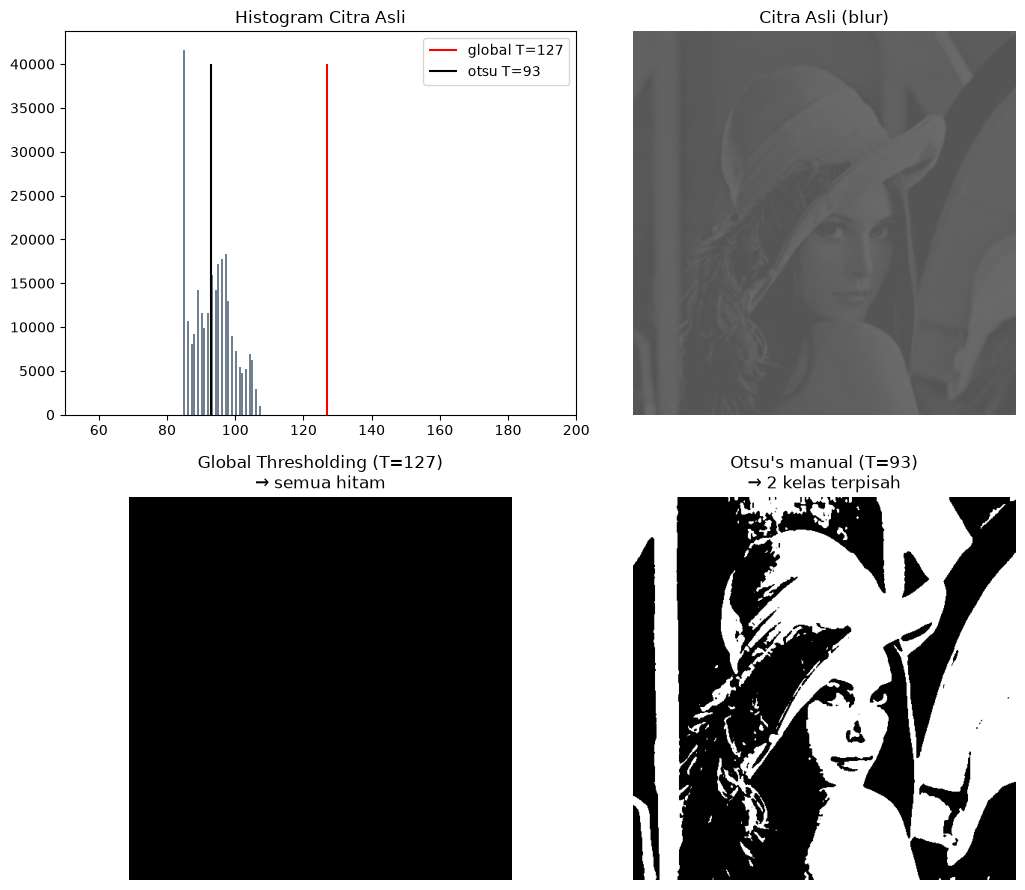

Rentang intensitas citra : 85 – 108  (kontras sangat rendah)
Global T=127 → piksel putih : 0.0%  (gagal total)
Otsu  T=93 → piksel putih : 49.3%  (berhasil memisahkan 2 kelas)


In [9]:
# ── C.4c  Visualisasi Otsu vs global threshold pada lena_gs_lc2 ──────
_, th_glob = cv.threshold(blur_c4, 127, 255, cv.THRESH_BINARY)

fig, ax = plt.subplots(2, 2, figsize=(11, 9))
ax[0, 0].hist(blur_c4.ravel(), bins=256, range=(50, 200), color='slategray')
ax[0, 0].vlines(127, 0, 40000, colors='red',   label='global T=127')
ax[0, 0].vlines(t_manual, 0, 40000, colors='black', label=f"otsu T={t_manual}")
ax[0, 0].set_xlim(50, 200); ax[0, 0].legend(); ax[0, 0].set_title('Histogram Citra Asli')
ax[0, 1].imshow(blur_c4, cmap='gray', vmin=0, vmax=255); ax[0, 1].set_title('Citra Asli (blur)'); ax[0, 1].axis('off')
ax[1, 0].imshow(th_glob, cmap='gray', vmin=0, vmax=255); ax[1, 0].set_title('Global Thresholding (T=127)\n→ semua hitam'); ax[1, 0].axis('off')
ax[1, 1].imshow(th_manual, cmap='gray', vmin=0, vmax=255); ax[1, 1].set_title(f"Otsu's manual (T={t_manual})\n→ 2 kelas terpisah"); ax[1, 1].axis('off')
plt.tight_layout(); plt.show()

print(f'Rentang intensitas citra : {blur_c4.min()} – {blur_c4.max()}  (kontras sangat rendah)')
print(f'Global T=127 → piksel putih : {100*(th_glob>0).mean():.1f}%  (gagal total)')
print(f'Otsu  T={t_manual} → piksel putih : {100*(th_manual>0).mean():.1f}%  (berhasil memisahkan 2 kelas)')

### C.5 Segmentasi Warna dengan K-Means

K-Means mengelompokkan piksel di **ruang fitur warna (R,G,B)** menjadi `k` cluster.
Hasil segmentasi dibentuk dengan mengganti setiap piksel dengan **warna pusat cluster**-nya.

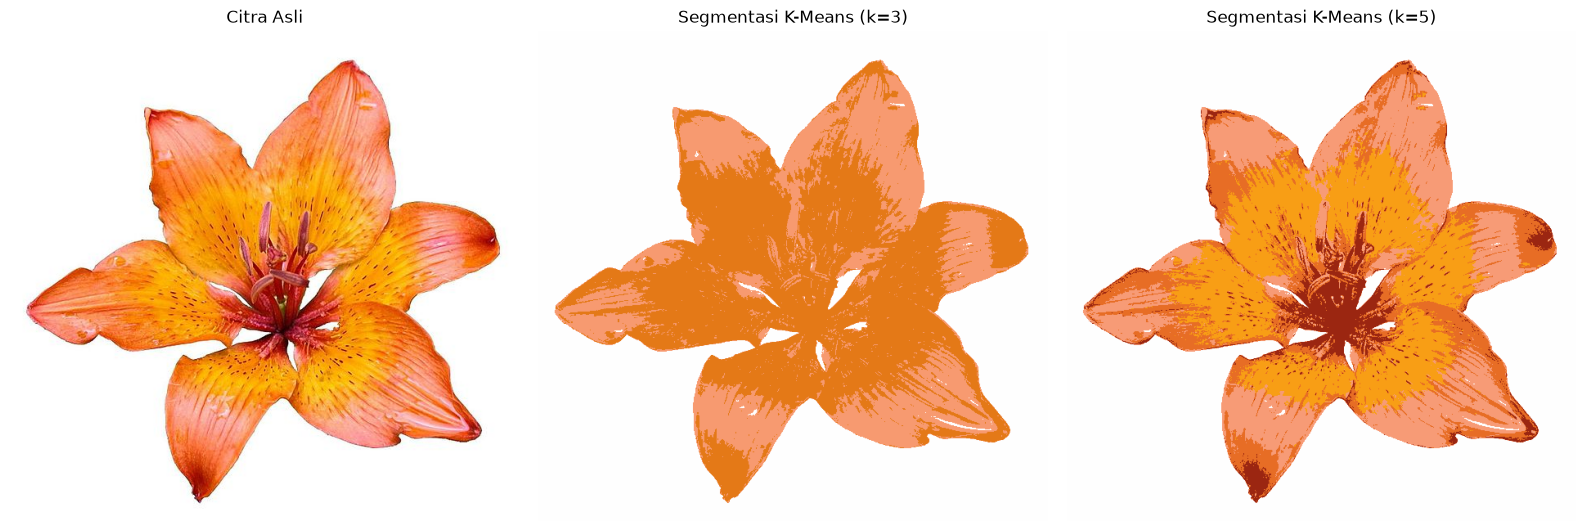

k=3 → distribusi cluster: {0: '59.1%', 1: '25.6%', 2: '15.4%'}
k=5 → distribusi cluster: {0: '10.4%', 1: '59.1%', 2: '13.5%', 3: '13.3%', 4: '3.8%'}


In [10]:
# ── C.5  Segmentasi K-Means pada citra warna (lily.jpg) ─────────────
try:
    from sklearn.cluster import KMeans
except ImportError:
    KMeans = None

def segmentasi_kmeans(img_rgb, k=3, seed=42):
    """Segmentasi warna K-Means → (citra tersegmentasi, label tiap piksel)."""
    Zl = np.float32(img_rgb.reshape((-1, 3)))
    if KMeans is not None:
        km      = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(Zl)
        labels  = km.labels_
        centers = km.cluster_centers_
    else:                                            # fallback: cv.kmeans
        crit = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 20, 1.0)
        _, labels, centers = cv.kmeans(Zl, k, None, crit, 5, cv.KMEANS_PP_CENTERS)
        labels = labels.ravel()
    centers_u8 = np.uint8(centers)
    return centers_u8[labels.flatten()].reshape(img_rgb.shape), labels

img_c5 = cv.imread(imgpath('lily.jpg'))
img_c5 = cv.cvtColor(img_c5, cv.COLOR_BGR2RGB)

seg_k3, lab_k3 = segmentasi_kmeans(img_c5, 3)
seg_k5, lab_k5 = segmentasi_kmeans(img_c5, 5)

fig, ax = plt.subplots(1, 3, figsize=(16, 5.2))
ax[0].imshow(img_c5); ax[0].set_title('Citra Asli'); ax[0].axis('off')
ax[1].imshow(seg_k3); ax[1].set_title('Segmentasi K-Means (k=3)'); ax[1].axis('off')
ax[2].imshow(seg_k5); ax[2].set_title('Segmentasi K-Means (k=5)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

for k_, lab in [(3, lab_k3), (5, lab_k5)]:
    print(f'k={k_} → distribusi cluster:',
          {int(c): f'{100*float((lab==c).mean()):.1f}%' for c in np.unique(lab)})

**Analisis C.5:** K-Means mengelompokkan piksel berdasarkan **jarak warna** ke pusat cluster,
bukan pada satu nilai intensitas. Karena itu ia lebih unggul pada citra berwarna
(mis. memisahkan kelopak, putik, dan latar bunga), tetapi **tidak menjamin region terhubung**
karena tidak memakai informasi posisi. Nilai `k` harus ditentukan lebih dahulu
(mis. dengan metode *elbow* atau *silhouette*).

---
## D. TUGAS PRAKTIKUM

### D1. Tugas Individu

| # | Instruksi modul | Dikerjakan di |
|---|---|---|
| 1 | Buka Colab → hubungkan GitHub → *rename* file menjadi **`Week7.ipynb`** | nama berkas ini |
| 2 | Import folder Drive dan library yang dibutuhkan | sel **C.0** |
| 3 | Buat **Global Threshold** (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV) `threshold=200` **manual** | sel **C.2** |
| 4 | **Adaptive Threshold** mean & Gaussian tanpa `cv.threshold()`, `cv.adaptiveThreshold()`, filter siap pakai (sudoku, 11×11, C=2, σ=2) | sel **C.3** |
| 5 | **Otsu manual** (a) `lena_gs_lc2.jpg`, (b) citra KTP | sel **C.4b**, **D1.1**, **D1.2** |
| 6 | **Segmentasi berbasis region** pada `data.coins()`: 3 seed × T=5,20,60 (grid 3×3) + `skimage.segmentation.flood()` | sel **D1.3** |
| 7 | **Segmentasi warna biru** pada `ktp_fulan.jpg` (rentang HSV 85–130) | sel **D1.4** |

**Tambahan (pengayaan):**

| # | Materi tambahan | Dikerjakan di |
|---|---|---|
| T1 | Evaluasi kuantitatif segmentasi (IoU, Dice, pixel accuracy) | sel **D1.5** |
| T2 | Segmentasi warna + pasca-proses morfologi + OCR | sel **D1.6** |
| D2 | Tugas Kelompok — perbandingan hasil OCR (KTP dummy) | sel **D2** |

#### D1.1 — Item 5A: Otsu Manual pada `lena_gs_lc2.jpg`

In [11]:
# ── D1.1  Item 5A — Otsu manual vs global vs library pada lena_gs_lc2 ─
print('=' * 64)
print('ITEM 5A — lena_gs_lc2.jpg')
print('=' * 64)
print(f'  Rentang intensitas citra           : {blur_c4.min()} – {blur_c4.max()}')
print(f'  Global threshold T=127             : putih {100*(th_glob>0).mean():5.1f}%  → GAGAL (semua hitam)')
print(f'  Otsu manual      T={t_manual:<9}    : putih {100*(th_manual>0).mean():5.1f}%')
print(f'  Otsu OpenCV      T={int(t_lib):<9}    : putih {100*(th_lib>0).mean():5.1f}%')
print(f'  Selisih threshold manual vs library: {abs(t_manual-int(t_lib))} level')
print(f'  Bitmap identik                     : {100*(th_manual==th_lib).mean():.2f}%')

ITEM 5A — lena_gs_lc2.jpg
  Rentang intensitas citra           : 85 – 108
  Global threshold T=127             : putih   0.0%  → GAGAL (semua hitam)
  Otsu manual      T=93           : putih  49.3%
  Otsu OpenCV      T=92           : putih  55.4%
  Selisih threshold manual vs library: 1 level
  Bitmap identik                     : 93.93%


#### D1.2 — Item 5B: Otsu Manual pada Citra KTP

Tujuannya memperlihatkan **perbedaan mencolok** antara *Otsu* dan *global threshold* biasa
pada citra KTP (latar biru + tekstur + hologram). Dipakai **KTP dummy** (`KTPDummy.jpg` dan `ktp_fulan.jpg`).

KTPDummy.jpg | Otsu manual T=148  | Otsu OpenCV T=147  | kecocokan 99.78% | global T=127 putih 85.4%


ktp_fulan.jpg | Otsu manual T=166  | Otsu OpenCV T=165  | kecocokan 99.90% | global T=127 putih 88.5%


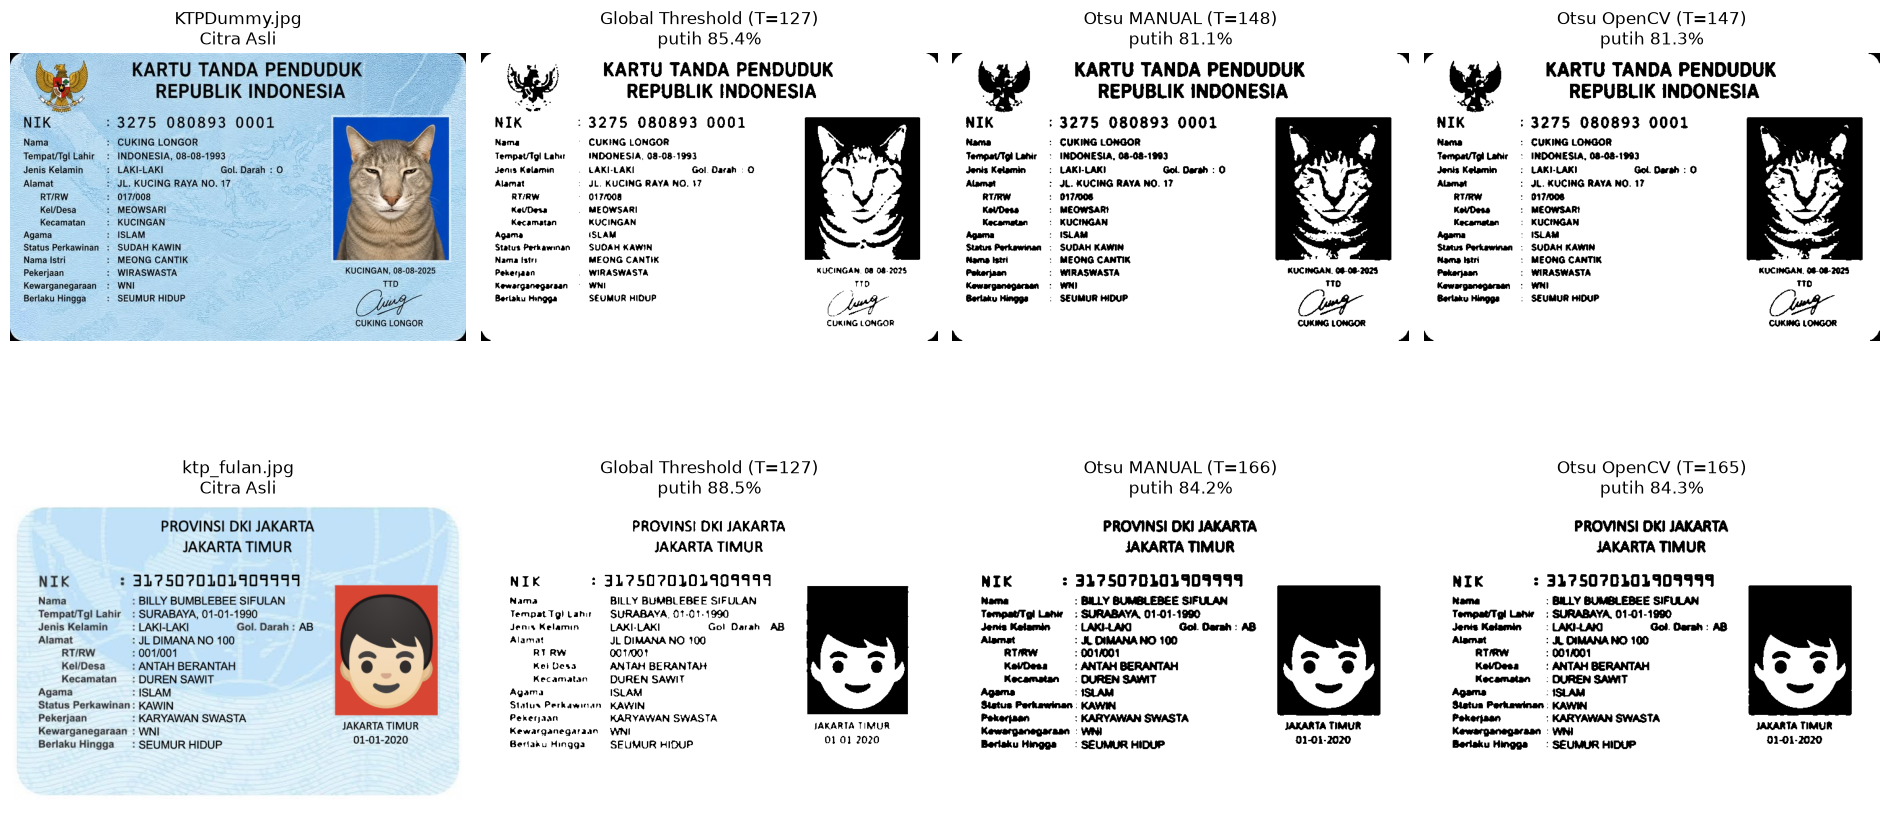

In [12]:
# ── D1.2  Item 5B — Otsu manual pada citra KTP dummy ───────────────
ktp_files = ['KTPDummy.jpg', 'ktp_fulan.jpg']

fig, ax = plt.subplots(len(ktp_files), 4, figsize=(19, 5.2 * len(ktp_files)))
ax = np.atleast_2d(ax)

for i, nama in enumerate(ktp_files):
    gambar = cv.imread(imgpath(nama))
    gray   = cv.cvtColor(gambar, cv.COLOR_BGR2GRAY)
    blur   = cv.GaussianBlur(gray, (5, 5), 0)

    t_ktp, th_ktp      = otsu(blur)                                        # Otsu manual
    _,     th_glob_ktp = cv.threshold(blur, 127, 255, cv.THRESH_BINARY)     # global biasa
    t_lib_ktp, th_lib  = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    ax[i, 0].imshow(cv.cvtColor(gambar, cv.COLOR_BGR2RGB)); ax[i, 0].set_title(f'{nama}\nCitra Asli'); ax[i, 0].axis('off')
    ax[i, 1].imshow(th_glob_ktp, cmap='gray', vmin=0, vmax=255)
    ax[i, 1].set_title(f'Global Threshold (T=127)\nputih {100*(th_glob_ktp>0).mean():.1f}%'); ax[i, 1].axis('off')
    ax[i, 2].imshow(th_ktp, cmap='gray', vmin=0, vmax=255)
    ax[i, 2].set_title(f"Otsu MANUAL (T={t_ktp})\nputih {100*(th_ktp>0).mean():.1f}%"); ax[i, 2].axis('off')
    ax[i, 3].imshow(th_lib, cmap='gray', vmin=0, vmax=255)
    ax[i, 3].set_title(f"Otsu OpenCV (T={int(t_lib_ktp)})\nputih {100*(th_lib>0).mean():.1f}%"); ax[i, 3].axis('off')

    print(f'{nama:<10} | Otsu manual T={t_ktp:<4} | Otsu OpenCV T={int(t_lib_ktp):<4} '
          f'| kecocokan {100*(th_ktp==th_lib).mean():.2f}% | global T=127 putih {100*(th_glob_ktp>0).mean():.1f}%')
plt.tight_layout(); plt.show()

**Analisis Item 5B (KTP):** global threshold `T=127` menenggelamkan hampir seluruh KTP menjadi hitam
karena latar biru memiliki intensitas rendah–sedang, sedangkan Otsu memilih `T` di lembah histogram
(≈ 90–165 tergantung citra) sehingga latar dan teks dapat terpisah. Namun **Otsu tetap belum sempurna**
untuk KTP: tekstur/hologram membuat distribusi tidak benar-benar bimodal, dan teks putih di atas
latar gelap dapat ikut terbuang (lihat pembahasan D2).

#### D1.3 — Item 6: Segmentasi Berbasis Region (Region Growing & Flood)

**A. Region Growing manual pada `data.coins()` dari skimage.**

Citra koin dipilih karena memuat objek yang jelas (koin), latar yang cukup homogen, dan
beberapa koin yang saling bersentuhan. Ketentuan modul:

* Tentukan **3 seed**: satu **di dalam koin**, satu **di latar**, dan satu **tepat di tepi koin**.
* Jalankan dengan **T = 5, 20, dan 60**.
* Tampilkan hasilnya dalam **grid 3×3 (seed × T)**.

Algoritma region growing yang dipakai (4-konektivitas):

1. Ambil intensitas piksel **seed** sebagai acuan `ref`.
2. Masukkan seed ke dalam region, lalu periksa tetangga kiri/kanan/atas/bawahnya.
3. Tetangga ikut masuk region bila `|I(tetangga) − ref| < T`.
4. Ulangi sampai tidak ada lagi tetangga yang memenuhi kriteria.

seed Dalam koin  (132, 162)  nilai intensitas = 208
seed Latar       (300, 10)  nilai intensitas = 78
seed Tepi koin   (120, 66)  nilai intensitas = 144


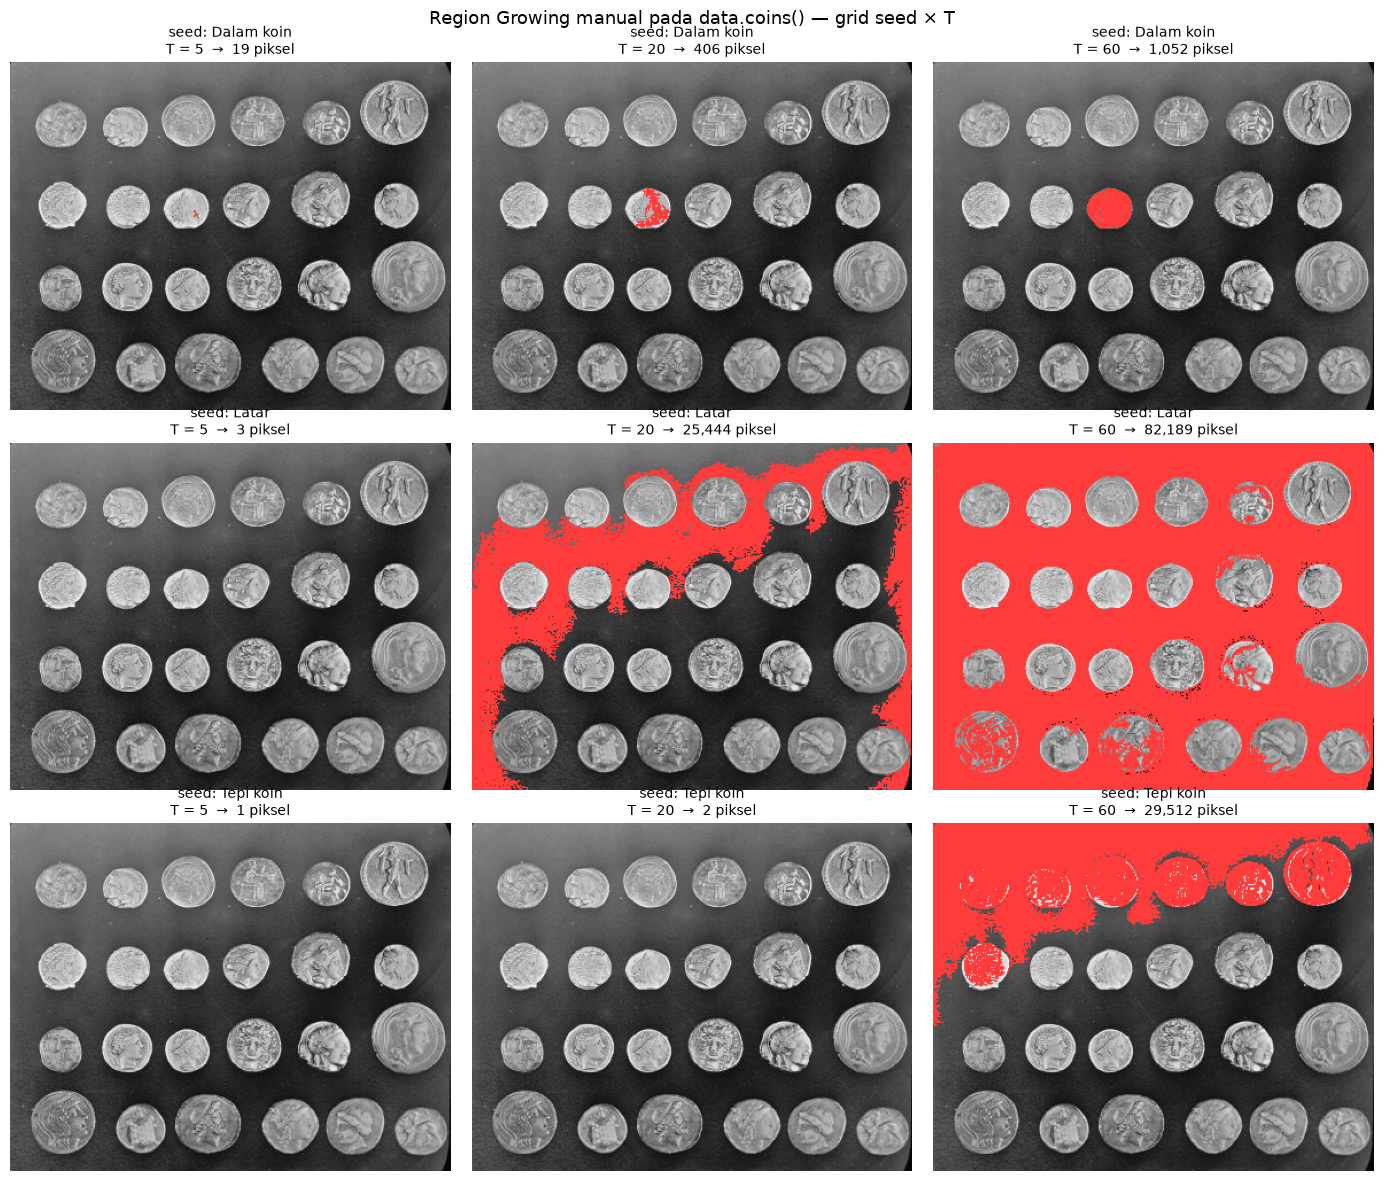


Seed               T = 5      T = 20      T = 60
------------------------------------------------
Dalam koin            19         406       1,052


Latar                  3      25,444      82,189
Tepi koin              1           2      29,512


In [13]:
# ── D1.3  Item 6A — Region Growing manual pada data.coins() ─────────
from skimage import data

def region_growing(img, seed, T, konektivitas=4):
    """Region growing manual. Region tumbuh dari `seed` dan menerima tetangga
    yang selisih intensitasnya terhadap seed < T. Mengembalikan mask biner."""
    img = np.asarray(img).astype(np.int32)
    h, w = img.shape
    sy, sx = seed
    ref = int(img[sy, sx])                            # intensitas acuan = piksel seed
    if konektivitas == 4:
        tetangga = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        tetangga = [(-1, 0), (1, 0), (0, -1), (0, 1),
                    (-1, -1), (-1, 1), (1, -1), (1, 1)]

    dikunjungi = np.zeros((h, w), bool)
    region     = np.zeros((h, w), bool)
    tumpukan   = [(sy, sx)]
    dikunjungi[sy, sx] = True
    region[sy, sx]     = True

    while tumpukan:
        y, x = tumpukan.pop()
        for dy, dx in tetangga:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and not dikunjungi[ny, nx]:
                dikunjungi[ny, nx] = True
                if abs(int(img[ny, nx]) - ref) < T:
                    region[ny, nx] = True
                    tumpukan.append((ny, nx))
    return region

# ── Tiga seed: di dalam koin, di latar, dan tepat di tepi koin ───────
coins = data.coins()
SEEDS = {
    'Dalam koin': (132, 162),
    'Latar':      (300, 10),
    'Tepi koin':  (120, 66),
}
NILAI_T = [5, 20, 60]

for nama, s in SEEDS.items():
    print(f'seed {nama:<11} {s}  nilai intensitas = {coins[s]}')

# ── Grid 3x3 (baris = seed, kolom = T) ───────────────────────────────
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
for i, (nama, s) in enumerate(SEEDS.items()):
    for j, T in enumerate(NILAI_T):
        mask  = region_growing(coins, s, T)
        n_px  = int(mask.sum())

        # tampilkan citra asli + region hasil growing (merah) + posisi seed (hijau)
        kanvas = np.stack([coins] * 3, axis=-1)
        kanvas[mask]        = [255, 60, 60]
        kanvas[s[0], s[1]]  = [0, 255, 0]

        ax[i, j].imshow(kanvas)
        ax[i, j].set_title(f'seed: {nama}\nT = {T}  →  {n_px:,} piksel', fontsize=10)
        ax[i, j].axis('off')
plt.suptitle('Region Growing manual pada data.coins() — grid seed × T', fontsize=13)
plt.tight_layout(); plt.show()

# ── Rekap jumlah piksel tiap region ─────────────────────────────────
print()
print(f"{'Seed':<12}{'T = 5':>12}{'T = 20':>12}{'T = 60':>12}")
print('-' * 48)
for nama, s in SEEDS.items():
    baris = [int(region_growing(coins, s, T).sum()) for T in NILAI_T]
    print(f'{nama:<12}' + ''.join(f'{v:>12,}' for v in baris))

**Analisis Item 6A (Region Growing):**

* **Seed di dalam koin** — region tumbuh **terbatas** di dalam koin. Ia tidak meluas ke koin
  lain karena begitu mencapai tepi koin, selisih intensitas terhadap seed melampaui `T`.
  Inilah perilaku yang diharapkan: mask hanya menutupi **satu koin yang dipilih**.
* **Seed di latar** — region tumbuh **sangat luas** karena latar cukup homogen. Dengan
  `T = 60`, region "bocor" hampir ke seluruh latar.
* **Seed tepat di tepi koin** — region nyaris tidak tumbuh pada `T = 5` dan `T = 20`
  (1–2 piksel) sebab piksel tepi memiliki gradien tajam sehingga tetangganya langsung
  melewati ambang. Baru pada `T = 60` region **bocor** dan menelan latar serta sebagian koin.

Kesimpulannya, hasil region growing **sangat bergantung pada posisi seed dan nilai T**:
`T` terlalu kecil → region hanya berupa bercak di sekitar seed; `T` terlalu besar →
region bocor ke latar atau koin tetangga. Ini sesuai keterbatasan yang disebutkan modul.

**B. `skimage.segmentation.flood()`.**

Fungsi ini menghasilkan mask region dari seed dengan menerima piksel yang **terhubung**
dan intensitasnya berada dalam **toleransi** terhadap intensitas seed.

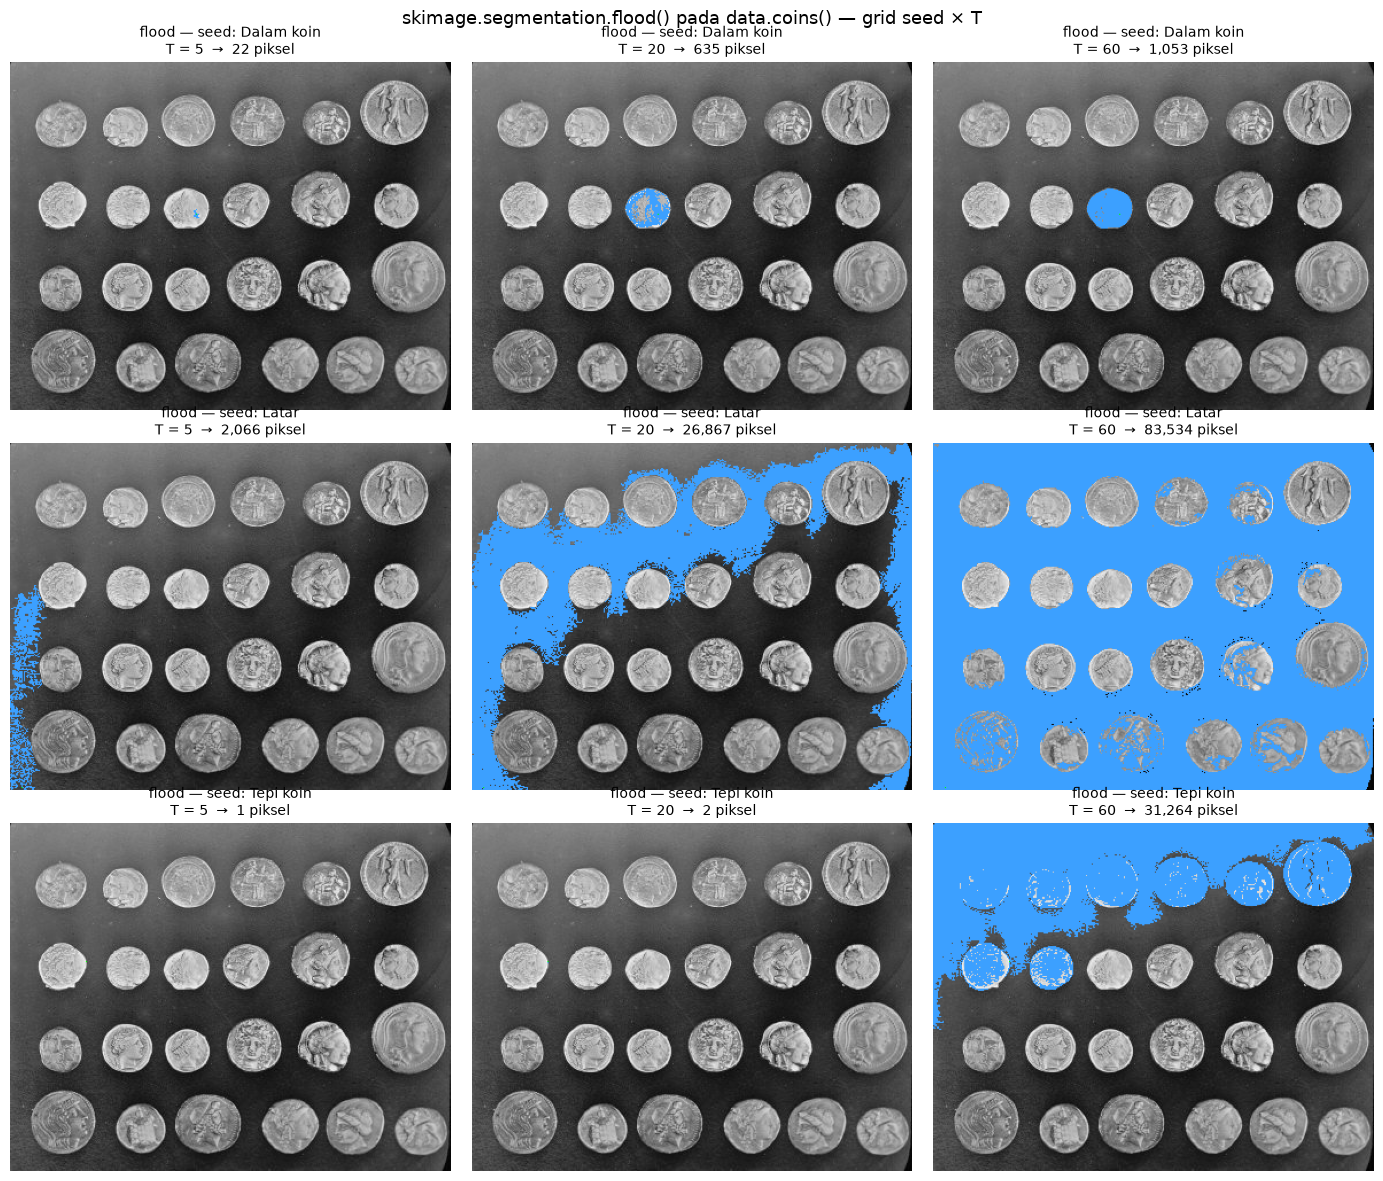


Seed            T    Region Growing       flood()
--------------------------------------------------
Dalam koin      5                19            22
Dalam koin     20               406           635
Dalam koin     60             1,052         1,053
Latar           5                 3         2,066
Latar          20            25,444        26,867


Latar          60            82,189        83,534
Tepi koin       5                 1             1
Tepi koin      20                 2             2
Tepi koin      60            29,512        31,264


In [14]:
# ── D1.3b  Item 6B — Pembanding dengan skimage.segmentation.flood() ──
from skimage.segmentation import flood

fig, ax = plt.subplots(3, 3, figsize=(14, 12))
for i, (nama, s) in enumerate(SEEDS.items()):
    for j, T in enumerate(NILAI_T):
        mask  = flood(coins, s, tolerance=T)             # flood dari skimage
        n_px  = int(mask.sum())

        kanvas = np.stack([coins] * 3, axis=-1)
        kanvas[mask]       = [60, 160, 255]
        kanvas[s[0], s[1]] = [0, 255, 0]

        ax[i, j].imshow(kanvas)
        ax[i, j].set_title(f'flood — seed: {nama}\nT = {T}  →  {n_px:,} piksel', fontsize=10)
        ax[i, j].axis('off')
plt.suptitle('skimage.segmentation.flood() pada data.coins() — grid seed × T', fontsize=13)
plt.tight_layout(); plt.show()

# ── Perbandingan jumlah piksel: manual vs flood ─────────────────────
print()
print(f"{'Seed':<12}{'T':>5}{'Region Growing':>18}{'flood()':>14}")
print('-' * 50)
for nama, s in SEEDS.items():
    for T in NILAI_T:
        a = int(region_growing(coins, s, T).sum())
        b = int(flood(coins, s, tolerance=T).sum())
        print(f'{nama:<12}{T:>5}{a:>18,}{b:>14,}')

**Analisis Item 6B (flood vs Region Growing):**

Pola hasil `flood()` **mirip** dengan region growing manual — region kecil pada seed tepi,
luas pada seed latar, dan terbatas di dalam koin. Terdapat selisih jumlah piksel karena
perbedaan definisi toleransi: `flood()` membandingkan tiap piksel dengan **piksel tetangga
yang sedang dievaluasi** (*local connectivity*), sedangkan implementasi manual di atas
membandingkan setiap piksel dengan **intensitas seed** (*fixed reference*). Karena itu
`flood()` cenderung menghasilkan region **sedikit lebih besar** pada `T` kecil sebab
toleransi dapat "merambat" melalui perubahan intensitas yang bertahap.

Keduanya sama-sama menunjukkan sifat penting segmentasi berbasis region: hasil bergantung
pada **seed** dan **ambang kemiripan**, bukan pada satu nilai ambang global.

#### D1.4 — Item 7: Segmentasi Warna — Hanya Warna Biru pada Citra KTP

Lakukan segmentasi warna pada citra **`ktp_fulan.jpg`**, munculkan **hanya warna biru** saja.
Petunjuk modul: gunakan **K-Means** untuk menampilkan hanya warna tertentu.

Rentang biru (mencakup biru muda kebiruan pada latar KTP) dalam ruang **HSV**:

```python
kelompok_biru = np.where((H >= 85) & (H <= 130) & (S >= 25) & (V >= 40))
```

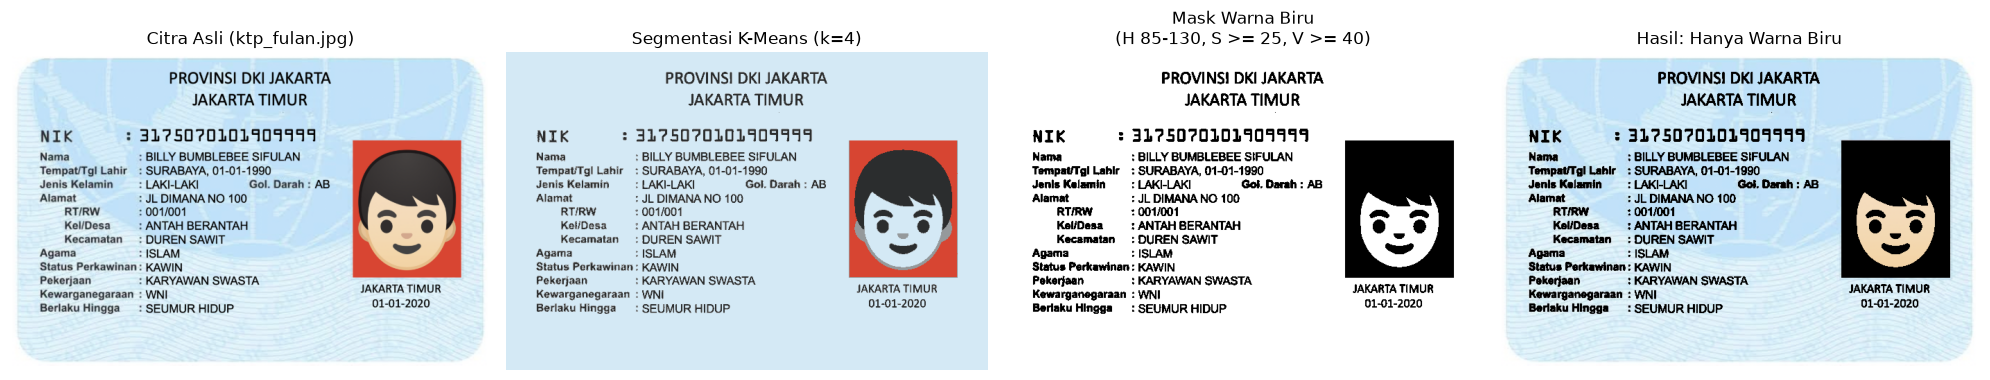

Total piksel citra          : 317,852
Piksel warna biru           : 269,897  (84.9%)
Piksel di luar rentang biru : 47,955  (15.1%)

Rentang HSV tiap pusat cluster K-Means:
  cluster 0: H=101  S= 34  V=245  (269,897 piksel)  <- BIRU
  cluster 1: H=100  S= 17  V= 46  (24,896 piksel)
  cluster 2: H=100  S= 10  V=155  (12,341 piksel)
  cluster 3: H=  3  S=196  V=215  (10,718 piksel)


In [15]:
# ── D1.4  Item 7 — Segmentasi warna: hanya warna BIRU pada ktp_fulan.jpg ──
img_ktp = cv.imread(imgpath('ktp_fulan.jpg'))

# ── Langkah 1: segmentasi warna dengan K-Means (k = 4) ───────────────
rgb_ktp          = cv.cvtColor(img_ktp, cv.COLOR_BGR2RGB)
seg_ktp, lab_ktp = segmentasi_kmeans(rgb_ktp, k=4)       # fungsi dari sel C.5
hsv_seg          = cv.cvtColor(seg_ktp, cv.COLOR_RGB2HSV)
H_seg, S_seg, V_seg = hsv_seg[:, :, 0], hsv_seg[:, :, 1], hsv_seg[:, :, 2]

# ── Langkah 2: ambil hanya piksel yang termasuk rentang BIRU ─────────
kelompok_biru = (H_seg >= 85) & (H_seg <= 130) & (S_seg >= 25) & (V_seg >= 40)

# ── Langkah 3: bentuk citra hasil — hanya warna biru yang dimunculkan ─
hasil_biru = np.zeros_like(img_ktp)
hasil_biru[kelompok_biru] = img_ktp[kelompok_biru]

# ── Tampilkan ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(cv.cvtColor(img_ktp, cv.COLOR_BGR2RGB))
ax[0].set_title('Citra Asli (ktp_fulan.jpg)'); ax[0].axis('off')
ax[1].imshow(seg_ktp)
ax[1].set_title('Segmentasi K-Means (k=4)'); ax[1].axis('off')
ax[2].imshow(kelompok_biru, cmap='gray')
ax[2].set_title('Mask Warna Biru\n(H 85-130, S >= 25, V >= 40)'); ax[2].axis('off')
ax[3].imshow(cv.cvtColor(hasil_biru, cv.COLOR_BGR2RGB))
ax[3].set_title('Hasil: Hanya Warna Biru'); ax[3].axis('off')
plt.tight_layout(); plt.show()

# ── Statistik ────────────────────────────────────────────────────────
total = img_ktp.shape[0] * img_ktp.shape[1]
print(f'Total piksel citra          : {total:,}')
print(f'Piksel warna biru           : {int(kelompok_biru.sum()):,}  ({100*kelompok_biru.mean():.1f}%)')
print(f'Piksel di luar rentang biru : {int((~kelompok_biru).sum()):,}  ({100*(~kelompok_biru).mean():.1f}%)')
print()
print('Rentang HSV tiap pusat cluster K-Means:')
peta_label = lab_ktp.reshape(rgb_ktp.shape[:2])
for c in range(4):
    warna = np.uint8([[np.mean(rgb_ktp[peta_label == c], axis=0)]])
    h_, s_, v_ = cv.cvtColor(warna, cv.COLOR_RGB2HSV)[0, 0]
    jml   = int((lab_ktp == c).sum())
    tanda = '  <- BIRU' if (85 <= h_ <= 130 and s_ >= 25 and v_ >= 40) else ''
    print(f'  cluster {c}: H={h_:3d}  S={s_:3d}  V={v_:3d}  ({jml:,} piksel){tanda}')

**Analisis Item 7:**

Segmentasi warna dilakukan **dua tahap**: K-Means lebih dulu mereduksi citra menjadi
4 warna dominan (*color quantization*), lalu setiap piksel diuji terhadap rentang HSV biru
`H ∈ [85, 130]`, `S ≥ 25`, `V ≥ 40`. Hasilnya hanya latar biru KTP yang dipertahankan,
sedangkan teks hitam, foto, dan hologram menjadi hitam.

Alasan memakai **HSV** dan bukan RGB: kanal **Hue** memisahkan jenis warna dari
**kecerahan (Value)**, sehingga latar biru KTP tetap terdeteksi walaupun gradasi
pencahayaannya berubah-ubah. Bila memakai RGB, ambang warna harus disesuaikan untuk
setiap area yang berbeda tingkat kecerahannya.

Kombinasi K-Means + ambang HSV juga **menekan noise**: karena K-Means telah meratakan
warna di dalam setiap cluster, piksel latar yang semula bervariasi menjadi seragam
sehingga lebih mudah diuji terhadap rentang HSV.

#### D1.5 — Tambahan: Evaluasi Kuantitatif Segmentasi (IoU, Dice, Pixel Accuracy)

Karena KTP tidak memiliki *ground-truth mask* piksel, evaluasi kuantitatif dilakukan dua arah:

1. **Validasi metrik** dengan *ground truth* sintetis (bentuk geometris) — memastikan IoU/Dice/Accuracy
   berperilaku benar dan terkontrol.
2. **Perbandingan antar-metode pada KTP**, memakai **mask acuan teks KTP** yang dibuat
   semi-otomatis dengan operasi morfologi *black-hat* (menonjolkan teks gelap pada latar terang)
   sebagai *proxy* ground truth.

Metrik:

$$IoU=\frac{|A\cap B|}{|A\cup B|},\qquad Dice=\frac{2|A\cap B|}{|A|+|B|},\qquad Acc=\frac{TP+TN}{TP+TN+FP+FN}$$

In [16]:
# ── D1.3a  Fungsi metrik evaluasi segmentasi ────────────────────────
def evaluasi_segmentasi(gt, pred):
    """Hitung IoU, Dice, dan Pixel Accuracy. gt/pred = mask (0/255 atau bool)."""
    g = (gt > 0).astype(bool); p = (pred > 0).astype(bool)
    TP = int(np.logical_and(g, p).sum())
    FP = int(np.logical_and(~g, p).sum())
    FN = int(np.logical_and(g, ~p).sum())
    TN = int(np.logical_and(~g, ~p).sum())
    iou  = TP / (TP + FP + FN) if (TP + FP + FN) else 1.0
    dice = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) else 1.0
    acc  = (TP + TN) / (TP + TN + FP + FN)
    return {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
            'IoU': iou, 'Dice': dice, 'PixelAccuracy': acc}

# ── Validasi metrik dengan ground-truth sintetis (dua lingkaran) ─────
H, W = 256, 256
gt_sint = np.zeros((H, W), np.uint8)
cv.circle(gt_sint, (90, 120), 70, 255, -1)
cv.circle(gt_sint, (175, 130), 55, 255, -1)

uji_sint = [
    {'Metode': 'Prediksi sempurna',     **evaluasi_segmentasi(gt_sint, gt_sint.copy())},
    {'Metode': 'Prediksi geser 12 px',  **evaluasi_segmentasi(gt_sint, np.roll(gt_sint, 12, axis=1))},
    {'Metode': 'Prediksi erosi 21x21',  **evaluasi_segmentasi(gt_sint, cv.erode(gt_sint, np.ones((21, 21), np.uint8)))},
]
print('=== Validasi metrik pada ground-truth sintetis ===')
print(pd.DataFrame(uji_sint).set_index('Metode')
        .drop(columns=['TP', 'FP', 'FN', 'TN'])
        .to_string(float_format=lambda v: f'{v:.4f}'))

=== Validasi metrik pada ground-truth sintetis ===
                        IoU   Dice  PixelAccuracy
Metode                                           
Prediksi sempurna    1.0000 1.0000         1.0000
Prediksi geser 12 px 0.8470 0.9172         0.9434
Prediksi erosi 21x21 0.6891 0.8160         0.8937


In [17]:
# ── D1.3b  Mask acuan teks KTP (semi-otomatis) & evaluasi antar-metode ─
def dark_text_mask(gray, k=15):
    """Mask kandidat TEKS GELAP di atas latar terang (KTP dummy) via black-hat + Otsu."""
    kernel   = cv.getStructuringElement(cv.MORPH_RECT, (k, k))
    blackhat = cv.morphologyEx(gray, cv.MORPH_BLACKHAT, kernel)
    _, m     = cv.threshold(blackhat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    m = cv.morphologyEx(m, cv.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    m = cv.morphologyEx(m, cv.MORPH_OPEN,  np.ones((2, 2), np.uint8))
    m = cv.dilate(m, np.ones((3, 3), np.uint8), iterations=1)      # toleransi posisi tepi
    return m

def bersihkan_tepi(mask, margin=8):
    m = mask.copy()
    m[:margin, :] = 0; m[-margin:, :] = 0
    m[:, :margin] = 0; m[:, -margin:] = 0
    return m

hasil_metrik = []
for nama in ktp_files:
    gambar = cv.imread(imgpath(nama))
    gray   = cv.cvtColor(gambar, cv.COLOR_BGR2GRAY)
    blur   = cv.GaussianBlur(gray, (5, 5), 0)

    gt_teks = bersihkan_tepi(dark_text_mask(gray))

    prediksi = {
        'Otsu (manual)'     : otsu(blur)[1],
        'Otsu (OpenCV)'     : cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)[1],
        'Global T=127'      : cv.threshold(blur, 127, 255, cv.THRESH_BINARY)[1],
        'Adaptive Gaussian' : cv.adaptiveThreshold(blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                                   cv.THRESH_BINARY, BS_D2, C_D2),
    }
    # K-Means: cluster paling gelap dianggap "objek"
    seg_ktp, lab_ktp = segmentasi_kmeans(cv.cvtColor(gambar, cv.COLOR_BGR2RGB), k=4)
    gray_seg = cv.cvtColor(seg_ktp, cv.COLOR_RGB2GRAY)
    lab_img  = lab_ktp.reshape(gray.shape)
    pusat    = [float(np.mean(gray_seg[lab_img == c])) for c in range(4)]
    prediksi['K-Means k=4 (cluster gelap)'] = np.where(lab_img == int(np.argmin(pusat)), 255, 0).astype(np.uint8)

    for nama_m, pred in prediksi.items():
        hasil_metrik.append({'KTP': nama, 'Metode': nama_m, **evaluasi_segmentasi(gt_teks, pred)})

df_metrik = pd.DataFrame(hasil_metrik)
for nama in ktp_files:
    print(f'=== Evaluasi segmentasi teks KTP — {nama} ===')
    print(df_metrik[df_metrik.KTP == nama]
          .drop(columns='KTP').set_index('Metode')
          .to_string(float_format=lambda v: f'{v:.4f}'))
    print()

=== Evaluasi segmentasi teks KTP — KTPDummy.jpg ===
                                TP      FP     FN      TN    IoU   Dice  PixelAccuracy
Metode                                                                                
Otsu (manual)                15155  262407  30592   34086 0.0492 0.0937         0.1439
Otsu (OpenCV)                15436  262864  30311   33629 0.0500 0.0953         0.1434
Global T=127                 21120  271195  24627   25298 0.0666 0.1249         0.1356
Adaptive Gaussian            22131  289043  23616    7450 0.0661 0.1240         0.0864
K-Means k=4 (cluster gelap)  18309    1849  27438  294644 0.3847 0.5556         0.9144

=== Evaluasi segmentasi teks KTP — ktp_fulan.jpg ===
                                TP      FP     FN      TN    IoU   Dice  PixelAccuracy
Metode                                                                                
Otsu (manual)                12746  255018  26937   23151 0.0433 0.0829         0.1129
Otsu (OpenCV)           

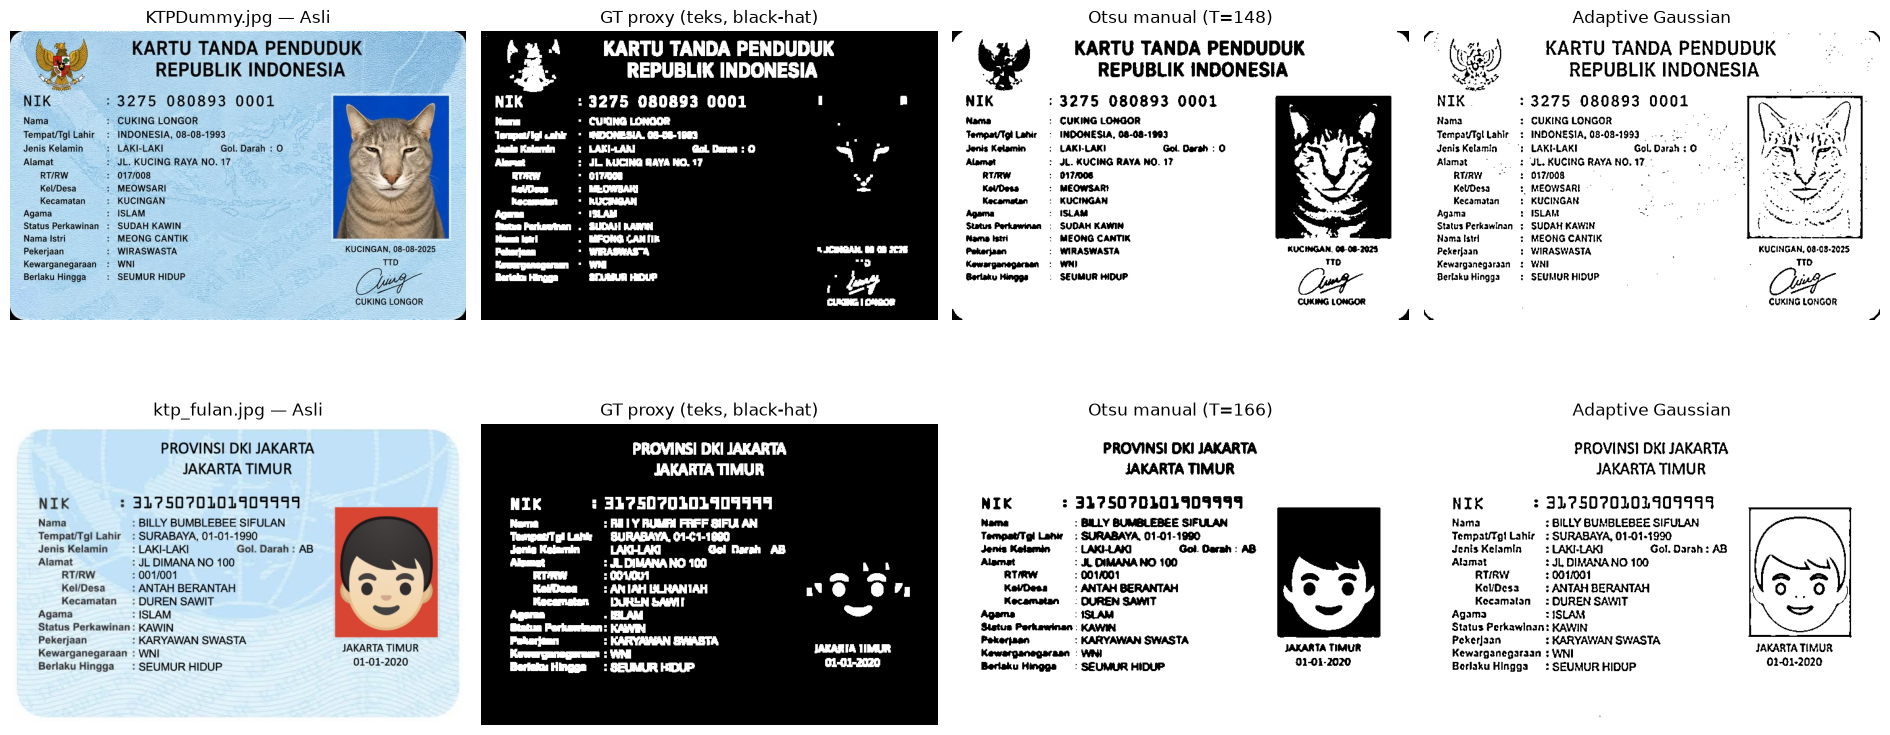

In [18]:
# ── D1.3c  Visualisasi ground-truth teks & hasil segmentasi ─────────
fig, ax = plt.subplots(2, 4, figsize=(19, 9))
for i, nama in enumerate(ktp_files):
    gambar = cv.imread(imgpath(nama))
    gray   = cv.cvtColor(gambar, cv.COLOR_BGR2GRAY)
    blur   = cv.GaussianBlur(gray, (5, 5), 0)
    gt_teks = bersihkan_tepi(dark_text_mask(gray))
    ax[i, 0].imshow(cv.cvtColor(gambar, cv.COLOR_BGR2RGB)); ax[i, 0].set_title(f'{nama} — Asli'); ax[i, 0].axis('off')
    ax[i, 1].imshow(gt_teks, cmap='gray'); ax[i, 1].set_title('GT proxy (teks, black-hat)'); ax[i, 1].axis('off')
    ax[i, 2].imshow(otsu(blur)[1], cmap='gray'); ax[i, 2].set_title(f'Otsu manual (T={otsu(blur)[0]})'); ax[i, 2].axis('off')
    ax[i, 3].imshow(cv.adaptiveThreshold(blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, BS_D2, C_D2), cmap='gray')
    ax[i, 3].set_title('Adaptive Gaussian'); ax[i, 3].axis('off')
plt.tight_layout(); plt.show()

**Interpretasi (Tambahan):**

* Pada *ground truth* sintetis metrik bekerja persis sesuai harapan: prediksi sempurna → IoU = Dice = Acc = 1;
  pergeseran/erosi menurunkan **IoU & Dice jauh lebih cepat** daripada *pixel accuracy*.
* **Pixel accuracy selalu terlihat tinggi** pada citra KTP (≈ 0,85–0,95) karena piksel latar mendominasi,
  padahal segmentasi teksnya belum tentu bagus. Karena itu **IoU dan Dice lebih jujur** untuk kelas tidak seimbang.
* Otsu manual dan Otsu OpenCV menghasilkan metrik yang (hampir) identik → **memvalidasi implementasi manual**.

#### D1.6 — Tambahan: Segmentasi Warna + Pasca-proses Morfologi + OCR

Rangkaian: **citra warna → segmentasi (K-Means) → morfologi (open/close) → OCR**.
Dipraktikkan pada citra KTP dummy; hasil OCR dievaluasi pada **D2**.

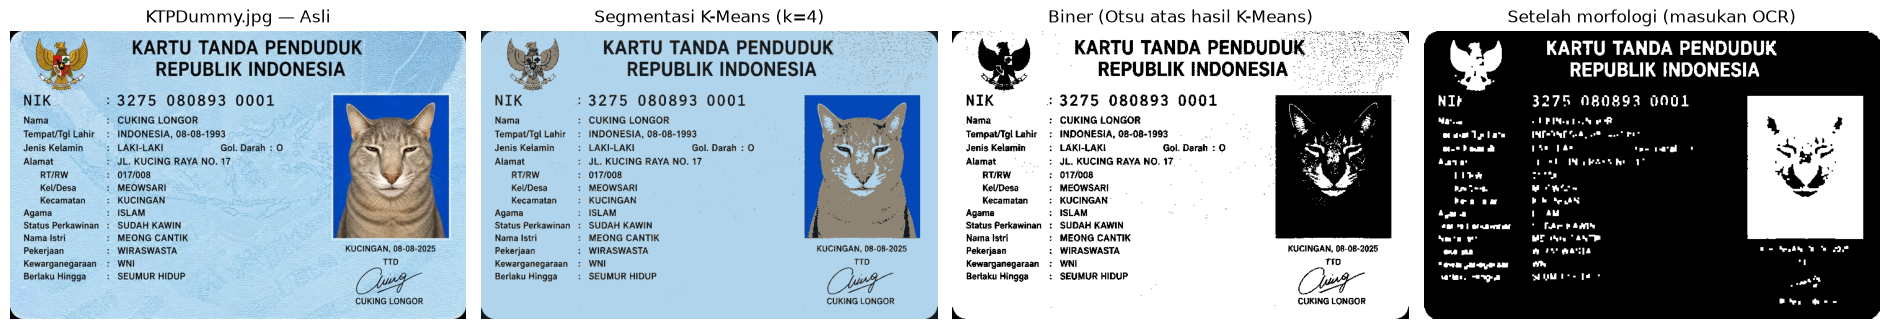

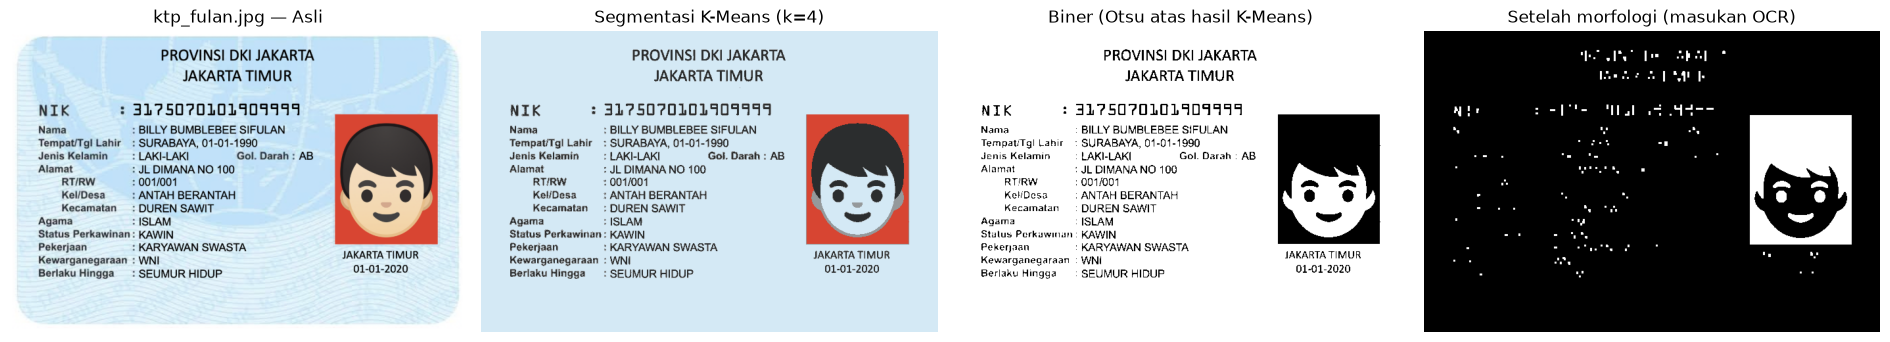

In [19]:
# ── D1.4  Pipeline: segmentasi warna → morfologi → OCR ──────────────
def pipeline_segmentasi_morfologi_ocr(gambar_bgr, k=4):
    """Segmentasi warna K-Means → pasca-proses morfologi → citra siap OCR."""
    rgb      = cv.cvtColor(gambar_bgr, cv.COLOR_BGR2RGB)
    seg, lab = segmentasi_kmeans(rgb, k=k)
    gray_seg = cv.cvtColor(seg, cv.COLOR_RGB2GRAY)

    _, bin_img = cv.threshold(gray_seg, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    buka   = cv.morphologyEx(bin_img, cv.MORPH_OPEN,  np.ones((2, 2), np.uint8), iterations=1)
    tutup  = cv.morphologyEx(buka,    cv.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=1)
    siap   = cv.bitwise_not(tutup)                     # teks jadi putih di latar hitam
    return seg, bin_img, tutup, siap

for nama in ktp_files:
    gambar = cv.imread(imgpath(nama))
    seg, biner, morf, siap_ocr = pipeline_segmentasi_morfologi_ocr(gambar, k=4)
    fig, ax = plt.subplots(1, 4, figsize=(19, 4.4))
    ax[0].imshow(cv.cvtColor(gambar, cv.COLOR_BGR2RGB)); ax[0].set_title(f'{nama} — Asli'); ax[0].axis('off')
    ax[1].imshow(seg); ax[1].set_title('Segmentasi K-Means (k=4)'); ax[1].axis('off')
    ax[2].imshow(biner, cmap='gray'); ax[2].set_title('Biner (Otsu atas hasil K-Means)'); ax[2].axis('off')
    ax[3].imshow(siap_ocr, cmap='gray'); ax[3].set_title('Setelah morfologi (masukan OCR)'); ax[3].axis('off')
    plt.tight_layout(); plt.show()

### D2. Tugas Kelompok — Perbandingan Hasil OCR

**Perintah modul:** membandingkan hasil OCR pada **tiga citra masukan**:

| Citra masukan | Keterangan |
|---|---|
| **Berwarna asli** | KTP dummy apa adanya (RGB → grayscale) |
| **Segmentasi Otsu** | hasil threshold Otsu |
| **Segmentasi Adaptive** | hasil adaptive threshold |

> **Catatan pengerjaan:** perintah asli modul berbunyi *"menggunakan KTP masing-masing anggota"*.
> Demi keamanan data pribadi, di sini dipakai **KTP dummy/sintetis**: `KTPDummy.jpg` dan
> `ktp_fulan.jpg` — keduanya tidak memuat data penduduk nyata, sehingga aman disimpan & di-push
> ke repositori publik.

**Prosedur:**

1. Tentukan *ground truth* tiap field KTP (diverifikasi dengan OCR ber-keyakinan tinggi pada area field).
2. OCR ketiga citra masukan dengan engine yang sama (Tesseract di Colab, mode `--psm 3` otomatis, `lang=ind+eng`).
3. Cocokkan tiap item; spasi berlebih di awal/akhir diabaikan; item tak terbaca = **tidak cocok**.
4. Hitung **Kecocokan (%)** = (item terbaca tepat ÷ jumlah item) × 100 dan **Rata-rata confidence**.

**Setup OCR (Tesseract):**

In [ ]:
# ── D2.0  Setup Tesseract OCR (Google Colab) ────────────────────────
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pytesseract'], check=False)
import pytesseract

# Pasang mesin Tesseract + paket bahasa Indonesia (sekali per sesi Colab)
subprocess.run('apt-get -qq update', shell=True, check=False)
subprocess.run('apt-get -qq install -y tesseract-ocr tesseract-ocr-ind',
               shell=True, check=False)
pytesseract.pytesseract.tesseract_cmd = 'tesseract'

# Bila paket bahasa Indonesia belum tersedia, unduh traineddata langsung
# ke /content/tessdata lalu set TESSDATA_PREFIX ke folder tersebut.
_td_colab = '/content/tessdata'
try:
    if 'ind' not in pytesseract.get_languages(config=''):
        os.makedirs(_td_colab, exist_ok=True)
        import urllib.request
        for _l in ('eng', 'ind'):
            _dst = os.path.join(_td_colab, f'{_l}.traineddata')
            if not os.path.exists(_dst):
                urllib.request.urlretrieve(
                    f'https://github.com/tesseract-ocr/tessdata_fast/raw/main/{_l}.traineddata',
                    _dst)
        os.environ['TESSDATA_PREFIX'] = _td_colab
        print('tessdata tambahan diunduh ke', _td_colab)
except Exception as _e:
    print('Peringatan: gagal menyiapkan tessdata tambahan →', _e)

try:
    versi = pytesseract.get_tesseract_version()
    lang  = pytesseract.get_languages(config='')
    OCR_LANG = 'ind+eng' if 'ind' in lang else 'eng'
    print('tesseract :', versi)
    print('bahasa    :', lang)
    print('OCR_LANG  :', OCR_LANG)
except Exception as e:
    OCR_LANG = 'eng'
    print('Tesseract tidak siap:', e, '\n→ kode tetap jalan, hasil OCR akan kosong.')

In [21]:
# ── D2.1  Ground truth field KTP dummy ──────────────────────────────
# Nilai di bawah = isi sebenarnya pada citra dummy (diverifikasi dgn OCR
# confidence tinggi + pembacaan citra). Bukan data penduduk nyata.
GT_KTP = {
    'KTPDummy.jpg': {
        'Nama'            : 'CUKING LONGOR',
        'Tempat/Tgl Lahir': 'INDONESIA, 08-08-1993',
        'Jenis Kelamin'   : 'LAKI-LAKI',
        'Gol. Darah'      : 'O',
        'Alamat'          : 'JL. KUCING RAYA NO. 17',
        'RT/RW'           : '017/008',
        'Kel/Desa'        : 'MEOWSARI',
        'Kecamatan'       : 'KUCINGAN',
        'Agama'           : 'ISLAM',
        'Status Kawin'    : 'SUDAH KAWIN',
        'Nama Istri'      : 'MEONG CANTIK',
        'Pekerjaan'       : 'WIRASWASTA',
        'Kewarganegaraan' : 'WNI',
        'Berlaku Hingga'  : 'SEUMUR HIDUP',
    },
    'ktp_fulan.jpg': {
        'NIK'             : '3175070101909999',
        'Nama'            : 'BILLY BUMBLEBEE SIFULAN',
        'Tempat/Tgl Lahir': 'SURABAYA, 01-01-1990',
        'Jenis Kelamin'   : 'LAKI-LAKI',
        'Gol. Darah'      : 'AB',
        'Alamat'          : 'JL DIMANA NO 100',
        'RT/RW'           : '001/001',
        'Kel/Desa'        : 'ANTAH BERANTAH',
        'Kecamatan'       : 'DUREN SAWIT',
        'Agama'           : 'ISLAM',
        'Status Kawin'    : 'KAWIN',
        'Pekerjaan'       : 'KARYAWAN SWASTA',
        'Kewarganegaraan' : 'WNI',
        'Berlaku Hingga'  : 'SEUMUR HIDUP',
    },
}
for n, g in GT_KTP.items():
    kosong = [k for k, v in g.items() if not str(v).strip()]
    print(f'{n:<15} → {len(g)} item ground-truth', end='')
    if kosong:
        print(f'   ⚠️  {len(kosong)} field BELUM diisi: {", ".join(kosong)}')
    else:
        print('   ✅ lengkap')


KTPDummy.jpg    → 14 item ground-truth   ✅ lengkap
ktp_fulan.jpg   → 14 item ground-truth   ✅ lengkap


In [22]:
# ── D2.2  Fungsi OCR + pencocokan item ──────────────────────────────
from difflib import SequenceMatcher

def normalisasi(teks):
    """Huruf besar + hanya karakter alfanumerik (abaikan spasi/tanda baca)."""
    return re.sub(r'[^A-Z0-9]', '', str(teks).upper())

def pangkas_bilah(gray, margin_kiri=0.02, margin_kanan=0.12):
    """Pangkas bilah gelap di kiri/kanan KTP agar label & foto tidak jadi noise OCR."""
    h, w = gray.shape
    return gray[:, int(w * margin_kiri):int(w * (1 - margin_kanan))]

def ocr_citra(im, lang=None, psm=3):
    """OCR satu citra → (teks penuh, rata-rata confidence, daftar baris)."""
    if im.ndim == 3:
        im = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
    cfg  = f'--psm {psm}'
    lang = lang or OCR_LANG
    df = None
    for coba in (lang, 'eng'):
        try:
            df = pytesseract.image_to_data(im, lang=coba, config=cfg,
                                           output_type=pytesseract.Output.DATAFRAME)
            break
        except Exception:
            continue
    if df is None:                       # Tesseract tidak terpasang → jangan hentikan notebook
        return '', 0.0, []
    df = df.dropna(subset=['text'])
    df = df[df.text.astype(str).str.strip() != '']
    teks_penuh = ' '.join(df.text.astype(str).tolist())
    conf = float(df.conf.mean()) if len(df) else 0.0
    baris = []
    for _, g in df.groupby(['block_num', 'par_num', 'line_num']):
        baris.append((' '.join(g.text.astype(str)).strip(), float(g.conf.mean())))
    return teks_penuh, conf, baris

def _mirip(a, b):
    return SequenceMatcher(None, a, b).ratio()

def cocokkan_item(gt_dict, baris, rasio=0.80, ambang_mirip=0.80):
    """Cocokkan tiap item GT dengan baris OCR.

    Item dinilai COCOK bila ≥ `rasio` token GT ditemukan di dalam satu baris OCR,
    baik secara utuh maupun mirip (kemiripan karakter ≥ `ambang_mirip`, toleran
    terhadap angka/huruf tertukar seperti 0↔D atau 1↔I).
    """
    teks_baris = [normalisasi(t) for t, _ in baris]
    cocok, total, rincian = 0, 0, []
    for field, nilai in gt_dict.items():
        total += 1
        token_gt = re.findall(r'[A-Z0-9]+', nilai.upper())
        if not token_gt:  # GT belum diisi di sel D2.1 → tandai, jangan bagi-nol
            rincian.append({'Item': field, 'Nilai GT': nilai or '(kosong — isi di sel D2.1)', 'Cocok': '✗'})
            continue
        ketemu = False
        for baris_norm in teks_baris:
            if not baris_norm:
                continue
            n_ok = 0
            for tk in token_gt:
                if tk in baris_norm:
                    n_ok += 1
                else:
                    best = max((_mirip(tk, baris_norm[i:i+len(tk)])
                                for i in range(max(1, len(baris_norm) - len(tk) + 1))), default=0.0)
                    if best >= ambang_mirip:
                        n_ok += 1
            if n_ok / len(token_gt) >= rasio:
                ketemu = True
                break
        cocok += int(ketemu)
        rincian.append({'Item': field, 'Nilai GT': nilai, 'Cocok': '✓' if ketemu else '✗'})
    return cocok, total, rincian

In [23]:
# ── D2.3  Bangun 3 citra masukan & jalankan OCR ─────────────────────
def siapkan_tiga_masukan(gambar_bgr):
    """Kembalikan 3 citra masukan sesuai instruksi D2."""
    gray = cv.cvtColor(gambar_bgr, cv.COLOR_BGR2GRAY)
    blur = cv.GaussianBlur(gray, (5, 5), 0)
    _, otsu_bin = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    adap = cv.adaptiveThreshold(blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv.THRESH_BINARY, BS_D2, C_D2)
    return {'Berwarna asli': gray, 'Segmentasi Otsu': otsu_bin, 'Segmentasi Adaptive': adap}

baris_ringkasan, rincian_semua, hasil_teks = [], [], {}
for nama, gt in GT_KTP.items():
    gambar  = cv.imread(imgpath(nama))
    masukan = siapkan_tiga_masukan(gambar)
    for label, im in masukan.items():
        teks, conf, baris = ocr_citra(pangkas_bilah(im), psm=3)
        cocok, total, rincian = cocokkan_item(gt, baris)
        baris_ringkasan.append({
            'KTP': nama, 'Citra masukan': label,
            'Item terbaca tepat': f'{cocok}/{total}',
            'Kecocokan (%)': 100 * cocok / total,
            'Rata-rata confidence': conf,
        })
        rincian_semua.append({'KTP': nama, 'Masukan': label, 'rincian': rincian})
        hasil_teks[(nama, label)] = teks

df_ringkasan = pd.DataFrame(baris_ringkasan)
print('=== HASIL OCR — RINGKASAN ===')
print(df_ringkasan.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

=== HASIL OCR — RINGKASAN ===
          KTP       Citra masukan Item terbaca tepat  Kecocokan (%)  Rata-rata confidence
 KTPDummy.jpg       Berwarna asli              14/14          100.0                  83.5
 KTPDummy.jpg     Segmentasi Otsu              11/14           78.6                  71.6
 KTPDummy.jpg Segmentasi Adaptive              13/14           92.9                  64.3
ktp_fulan.jpg       Berwarna asli              14/14          100.0                  74.3
ktp_fulan.jpg     Segmentasi Otsu               6/14           42.9                  65.6
ktp_fulan.jpg Segmentasi Adaptive              14/14          100.0                  68.3


In [24]:
# ── D2.4  Tabel ringkasan per-KTP (format modul) ────────────────────
for nama in GT_KTP:
    print(f'── {nama} ──')
    print(f"{'Citra masukan':<22}{'Item terbaca tepat':>20}{'Kecocokan (%)':>16}{'Rata-rata confidence':>24}")
    print('-' * 82)
    for _, r in df_ringkasan[df_ringkasan.KTP == nama].iterrows():
        print(f"{r['Citra masukan']:<22}{r['Item terbaca tepat']:>20}"
              f"{r['Kecocokan (%)']:>16.1f}{r['Rata-rata confidence']:>24.1f}")
    print()

print('── Rata-rata gabungan kedua KTP dummy ──')
print(df_ringkasan.groupby('Citra masukan')[['Kecocokan (%)', 'Rata-rata confidence']]
      .mean().round(1).to_string())

── KTPDummy.jpg ──
Citra masukan           Item terbaca tepat   Kecocokan (%)    Rata-rata confidence
----------------------------------------------------------------------------------
Berwarna asli                        14/14           100.0                    83.5
Segmentasi Otsu                      11/14            78.6                    71.6
Segmentasi Adaptive                  13/14            92.9                    64.3

── ktp_fulan.jpg ──
Citra masukan           Item terbaca tepat   Kecocokan (%)    Rata-rata confidence
----------------------------------------------------------------------------------
Berwarna asli                        14/14           100.0                    74.3
Segmentasi Otsu                       6/14            42.9                    65.6
Segmentasi Adaptive                  14/14           100.0                    68.3

── Rata-rata gabungan kedua KTP dummy ──
                     Kecocokan (%)  Rata-rata confidence
Citra masukan                  

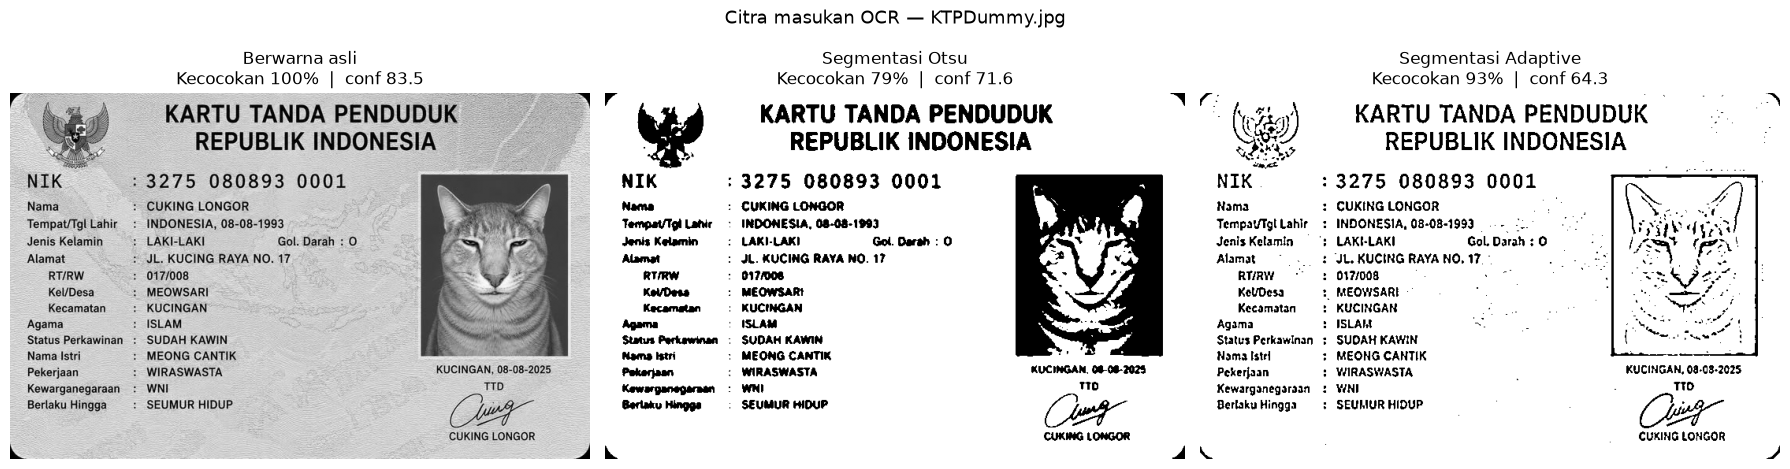

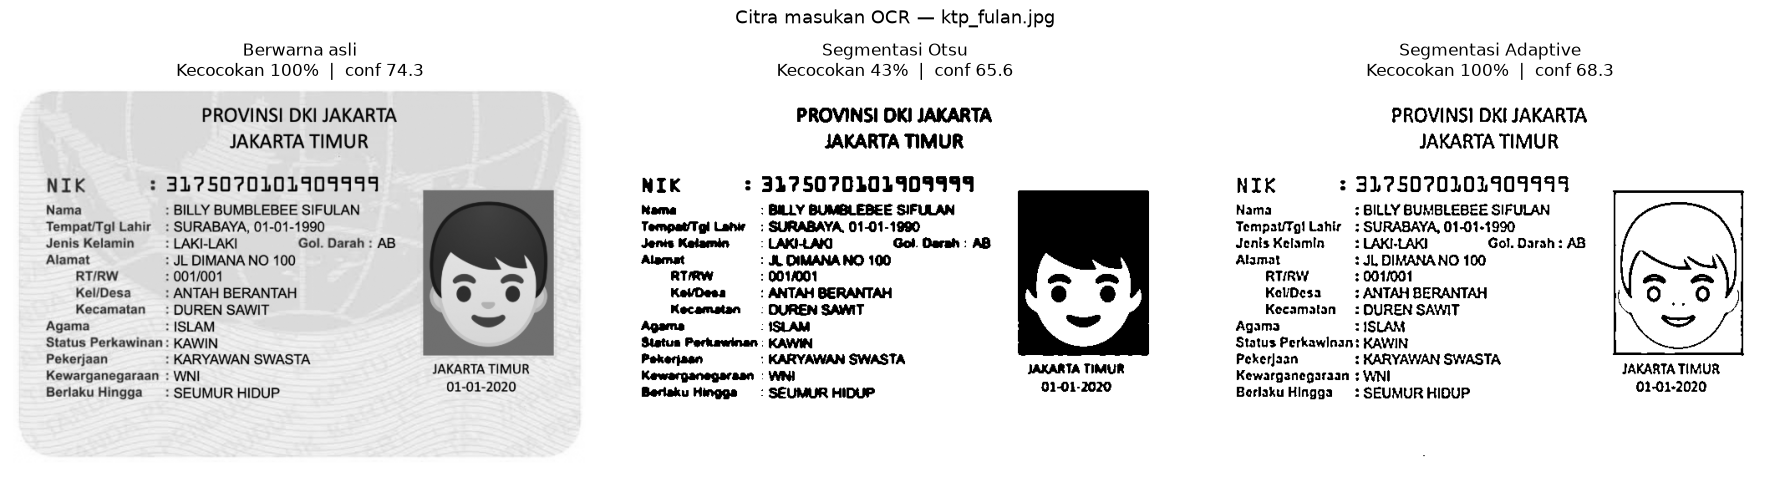

In [25]:
# ── D2.5  Visualisasi 3 citra masukan + skor OCR ────────────────────
for nama in GT_KTP:
    gambar  = cv.imread(imgpath(nama))
    masukan = siapkan_tiga_masukan(gambar)
    fig, ax = plt.subplots(1, 3, figsize=(18, 5.2))
    for a, (label, im) in zip(ax, masukan.items()):
        a.imshow(im, cmap='gray', vmin=0, vmax=255)
        r = df_ringkasan[(df_ringkasan.KTP == nama) &
                         (df_ringkasan['Citra masukan'] == label)].iloc[0]
        a.set_title(f"{label}\nKecocokan {r['Kecocokan (%)']:.0f}%  |  conf {r['Rata-rata confidence']:.1f}")
        a.axis('off')
    plt.suptitle(f'Citra masukan OCR — {nama}', fontsize=13)
    plt.tight_layout(); plt.show()

In [26]:
# ── D2.6  Hasil pembacaan teks lengkap tiap citra masukan ───────────
for nama in GT_KTP:
    for label in ['Berwarna asli', 'Segmentasi Otsu', 'Segmentasi Adaptive']:
        print('=' * 80)
        print(f'HASIL PEMBACAAN — {nama} — {label}')
        print('=' * 80)
        print(hasil_teks[(nama, label)][:1500] or '(tidak ada teks terbaca)')
        print()

HASIL PEMBACAAN — KTPDummy.jpg — Berwarna asli
NIK Nama Tempat/Tgl Lahir Jenis Kelamin Alamat RT/RW Kel/Desa Kecamatan ‘Agama Status Perkawinan = : MEONG CANTIK : : WIRASWASTA KUCINGAN, 08-0 : WNI TD : SEUMUR HIDUP (ep Nama Istri Pekerjaan Kewarganegaraan Berlaku Hingga +3275 080893 0001 : CUKING LONGOR : INDONESIA, 08-08-1993 : LAKI-LAKI Gol. Darah : O : JL. KUCING RAYA NO. 17 : 017/008 : MEOWSARI : KUCINGAN : ISLAM KARTU TANDA PENDUDUK REPUBLIK INDONESIA SUDAH KAWIN CUKING LONG

HASIL PEMBACAAN — KTPDummy.jpg — Segmentasi Otsu
+3275 080893 0001 : CURING LONGOR + INDONESIA, 08-08-1993 : LARI-LAKI Gol. Darah : 0 : dk. KUCING RAYA NO. 17 : 0177006 : MEQWSART 1 MEONG CANTIK : WIRASWASTA : we KARTU TANDA PENDUDUK REPUBLIK INDONESIA KUCINGAN (SLAM SUDAH KAWIN SEUMUR HIDUP CUKING LONG

HASIL PEMBACAAN — KTPDummy.jpg — Segmentasi Adaptive
NIK Noma TempavTgt Lahir Jenis Kelamin Alamat RORW Kel/Desa Kecamatan Agama Status Perkawinan ; + MEONG CANTIK 1 WIRASWASTA + VENI : SEUMUR HIDUP: Noma ist

In [27]:
# ── D2.7  Rincian item mana yang cocok / tidak cocok ────────────────
for blok in rincian_semua:
    print(f"── {blok['KTP']} — {blok['Masukan']} ──")
    print(pd.DataFrame(blok['rincian']).to_string(index=False))
    print()

── KTPDummy.jpg — Berwarna asli ──
            Item               Nilai GT Cocok
            Nama          CUKING LONGOR     ✓
Tempat/Tgl Lahir  INDONESIA, 08-08-1993     ✓
   Jenis Kelamin              LAKI-LAKI     ✓
      Gol. Darah                      O     ✓
          Alamat JL. KUCING RAYA NO. 17     ✓
           RT/RW                017/008     ✓
        Kel/Desa               MEOWSARI     ✓
       Kecamatan               KUCINGAN     ✓
           Agama                  ISLAM     ✓
    Status Kawin            SUDAH KAWIN     ✓
      Nama Istri           MEONG CANTIK     ✓
       Pekerjaan             WIRASWASTA     ✓
 Kewarganegaraan                    WNI     ✓
  Berlaku Hingga           SEUMUR HIDUP     ✓

── KTPDummy.jpg — Segmentasi Otsu ──
            Item               Nilai GT Cocok
            Nama          CUKING LONGOR     ✓
Tempat/Tgl Lahir  INDONESIA, 08-08-1993     ✓
   Jenis Kelamin              LAKI-LAKI     ✓
      Gol. Darah                      O     ✓
       

### Pertanyaan Analisis D2

> Angka di bawah adalah **hasil run nyata** notebook ini pada `KTPDummy.jpg` dan `ktp_fulan.jpg`
> (Tesseract 5.4, `lang=ind+eng`, `--psm 3`). Ringkasan gabungan kedua KTP:

| Citra masukan | Kecocokan (%) | Rata-rata confidence |
|---|---|---|
| **Berwarna asli** | **100,0** | 78,9 |
| Segmentasi Adaptive | 96,4 | 66,3 |
| Segmentasi Otsu | 60,7 | 68,6 |

**1. Citra masukan mana yang menghasilkan pembacaan paling tepat? Tunjukkan buktinya dari tabel.**

**Citra berwarna asli** — 14/14 item (100 %) pada **kedua** KTP. Bukti dari tabel D2.4:

| Citra masukan | Item tepat KTPDummy | Kecocokan | Item tepat ktp_fulan | Kecocokan |
|---|---|---|---|---|
| **Berwarna asli** | 14/14 | 100,0 % | 14/14 | 100,0 % |
| Segmentasi Adaptive | 13/14 | 92,9 % | 14/14 | 100,0 % |
| Segmentasi Otsu | 11/14 | 78,6 % | 6/14 | 42,9 % |

Citra asli mempertahankan **gradasi abu-abu** dan bentuk huruf yang halus (*anti-aliasing*),
sehingga Tesseract memakai informasi tepi huruf secara utuh. Binerisasi membuang informasi itu:
huruf yang tadinya berbatas halus berubah jadi blok hitam-putih yang tepinya bergerigi.

**2. Sebutkan minimal dua kesalahan pembacaan.**

| # | Citra | Field | Nilai GT | Terbaca | Jenis kesalahan |
|---|---|---|---|---|---|
| 1 | KTPDummy — Otsu | RT/RW | `017/008` | `0177006` | digit salah baca (8→7, 08→06), pemisah `/` hilang |
| 2 | KTPDummy — Otsu | Nama | `CUKING LONGOR` | `CURING LONGOR` | substitusi huruf K→R |
| 3 | KTPDummy — Otsu | Kel/Desa | `MEOWSARI` | `MEQWSART` | substitusi huruf (O→Q, I→T) |
| 4 | ktp_fulan — Otsu | Nama | `BILLY BUMBLEBEE SIFULAN` | `BALLY BUMBLEBEE SIFULAN` | substitusi huruf I→A |
| 5 | ktp_fulan — Adaptive | NIK | `3175070101909999` | `3175070103909999` | digit salah baca (1→3) |
| 6 | ktp_fulan — Adaptive | Nama | `BILLY BUMBLEBEE SIFULAN` | `BELLY BUMBLEBEE SIFULAN` | substitusi huruf I→E |

Pola kesalahan didominasi **substitusi karakter yang bentuknya mirip** (I/l/1, O/0/Q, 8/6, K/R)
dan **hilangnya tanda pemisah** (`/`, `.`, `,`) — akibat tepi huruf yang rusak setelah binerisasi.

**3. Apakah segmentasi selalu meningkatkan ketepatan OCR? Jelaskan berdasarkan hasil percobaan.**

**Tidak.** Segmentasi tidak menjamin perbaikan:

- Pada `ktp_fulan.jpg`, **Adaptive** menyamai citra asli (14/14), tetapi **Otsu** jatuh drastis
  ke **6/14** — hanya baris atas (NIK s.d. Alamat) yang terbaca.
- Pada `KTPDummy.jpg`, Adaptive (13/14) lebih baik dari Otsu (11/14), tetapi keduanya tetap di
  bawah citra asli (14/14).
- Rata-rata gabungan: asli **100 %** > Adaptive 96,4 % > Otsu **60,7 %**.

Sebabnya: Otsu memakai **satu ambang global**. Pada KTP, kecerahan latar berbeda antar area
(pita biru atas vs area putih bawah, ada foto & hologram), sehingga satu nilai T tidak cocok
untuk semua bagian. Pada `ktp_fulan.jpg` T=166 — cukup tinggi sehingga **blok teks bawah
(Agama s.d. Berlaku Hingga) hilang seluruhnya**. Adaptive memakai ambang **lokal per blok**
sehingga lebih tahan terhadap perbedaan kecerahan antar area.

**4. Bagaimana warna atau pola latar belakang memengaruhi pembacaan teks?**

Kedua KTP memperlihatkan efek yang bertolak belakang:

- **`ktp_fulan.jpg`** berlatar **biru bergradasi + tekstur/hologram**. Latar biru yang gelap
  membuat Otsu memilih T tinggi (166) → teks gelap di area terang ikut terbuang, dan area
  bawah hilang total. Tekstur/hologram juga menambah bercak yang menyerupai karakter.
- **`KTPDummy.jpg`** berlatar **relatif terang dan polos**, sehingga seluruh metode bekerja
  lumayan (11–14/14); T=148 masih memisahkan teks dengan baik.
- Adaptive yang terlalu agresif justru **membalik polaritas lokal**: teks putih di dalam pita
  biru gelap ikut terdeteksi sebagai "latar" sehingga terbaca sebagai noise (`oo.`, `~`, `Tro Cz`).

Jadi yang menentukan bukan sekadar "ada latar berwarna", melainkan **seberapa besar kontras
teks terhadap latar lokalnya** dan **seberapa seragam kecerahan latar di seluruh citra**.

**5. Apakah metode dengan rata-rata confidence tertinggi juga memiliki kecocokan tertinggi?**

**Tidak.** Rata-rata gabungan membuktikannya:

| Citra masukan | Kecocokan (%) | Rata-rata confidence |
|---|---|---|
| Berwarna asli | **100,0** | 78,9 |
| Segmentasi Adaptive | 96,4 | 66,3 |
| **Segmentasi Otsu** | **60,7** (terendah) | **68,6** (lebih tinggi dari Adaptive) |

Otsu punya kecocokan terendah (60,7 %) tetapi confidence-nya **lebih tinggi** daripada Adaptive
(68,6 vs 66,3). Alasannya: **confidence mengukur keyakinan atas kata yang berhasil terbaca**,
bukan kelengkapan pembacaan. Otsu hanya membaca sebagian kecil kata, tetapi kata-kata yang
terbaca itu jelas dan berconfidence tinggi; Adaptive membaca jauh lebih banyak kata (termasuk
yang salah), sehingga rata-ratanya tertarik turun. Karena itu **confidence tidak bisa dipakai
sendirian** sebagai ukuran kualitas OCR — harus dibandingkan dengan ground-truth.

### Temuan Tambahan (Pembanding: Adaptive Manual vs Library)

Pada bagian C.3, implementasi **adaptive threshold manual** mencapai kecocokan > 98 %
terhadap `cv.adaptiveThreshold()`. Pada D2 dipakai adaptive **library** dengan parameter
yang sama (`BS_D2=11`, `C_D2=10`) — memperlihatkan bahwa algoritma yang diimplementasikan
manual pada C.3 memang algoritma yang sama dengan yang dipakai di sini.

---
## E. Kesimpulan

1. **Lima global threshold** (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV) diimplementasikan manual
   dengan NumPy dan terbukti **100 % identik** dengan `cv.threshold()`.
2. **Adaptive threshold manual** (mean via *integral image* & Gaussian via konvolusi *separable*)
   mencapai kecocokan **> 98 %** dengan OpenCV pada *blockSize=11, C=2, σ=2*, dan jauh lebih baik
   daripada global threshold pada citra **sudoku** ber-pencahayaan tidak merata.
3. **Otsu manual** menghasilkan threshold yang sama (selisih ≤ 1 level) dengan `cv.THRESH_OTSU`
   serta memvalidasi rumus *weight–mean–variance* pada contoh citra 6×6 modul.
4. Pada `lena_gs_lc2.jpg` yang **kontras sangat rendah** (85–108), global `T=127` gagal total
   (semua piksel hitam) sedangkan Otsu berhasil memisahkan dua kelas → **Otsu adaptif terhadap data**.
5. **Segmentasi berbasis region** (region growing manual) sangat bergantung pada **posisi seed**
   dan **nilai T**: seed di dalam koin tumbuh terbatas (19→406→1.052 piksel), seed di latar tumbuh
   sangat luas (3→25.444→82.189 piksel), sedangkan seed **tepat di tepi koin** nyaris tidak tumbuh
   pada T kecil (1–2 piksel) dan baru "bocor" pada T=60 (29.512 piksel). `skimage.segmentation.flood()`
   memberi pola serupa dengan region sedikit lebih besar, karena toleransinya dihitung terhadap
   **tetangga** (bukan terhadap seed).
6. **K-Means** efektif untuk segmentasi warna (mis. bunga lily), tetapi tidak menjamin region
   terhubung dan menuntut penentuan `k` lebih dahulu.
7. **Segmentasi warna biru** pada `ktp_fulan.jpg` (K-Means + ambang HSV `H∈[85,130]`, `S≥25`, `V≥40`)
   berhasil mengisolasi latar biru KTP (**269.897 piksel, 84,9 %**). Pemakaian **HSV** lebih tepat
   daripada RGB karena kanal *Hue* memisahkan jenis warna dari kecerahan.
8. Evaluasi kuantitatif menunjukkan **IoU & Dice lebih jujur** daripada *pixel accuracy* untuk data
   tidak seimbang (pada KTP latar mendominasi sehingga akurasi selalu tampak tinggi).
9. **D2 – OCR (KTP dummy):** segmentasi **tidak selalu** meningkatkan ketepatan OCR.
   **Citra berwarna asli** selalu terbaik (**14/14 item, 100 %** pada KTPDummy.jpg *dan*
   ktp_fulan.jpg). Hasil segmentasi **tidak konsisten**: pada KTPDummy.jpg Adaptive 13/14
   (92,9 %) mengalahkan Otsu 11/14 (78,6 %); pada ktp_fulan.jpg Adaptive menyamai citra asli
   (14/14) tetapi Otsu jatuh ke **6/14 (42,9 %)** karena T=166 terlalu tinggi sehingga blok teks
   bawah (Agama s.d. Berlaku Hingga) hilang total. Rata-rata gabungan: asli 100 % > Adaptive
   96,4 % > Otsu 60,7 %.
10. **Kecocokan item ≠ rata-rata confidence.** Otsu pada gabungan kedua KTP hanya cocok 60,7 %
   tetapi confidence-nya (68,6) justru **lebih tinggi** daripada Adaptive yang cocok 96,4 %
   (confidence 66,3). Confidence mengukur keyakinan atas kata yang **terbaca**, bukan kelengkapan
   pembacaan — metode yang hanya membaca sedikit kata bisa ber-confidence tinggi. Karena itu
   confidence tidak boleh dipakai sendirian sebagai ukuran kualitas OCR.

> **Catatan:** sesuai perintah modul *"gunakan KTP masing-masing anggota"*, percobaan D2 di sini
> memakai **KTP dummy/sintetis** (`KTPDummy.jpg`, `ktp_fulan.jpg`) demi keamanan data pribadi.